# Customer Churn Classification: Predicting Customer Attrition with Machine Learning

## Business Context

This project builds and evaluates machine learning classification models to predict customer churn.

The goal is not only to classify customers, but also to evaluate the model using business-relevant metrics, analyze decision thresholds, and generate retention recommendations.

## Main Questions

1. How imbalanced is the churn problem?
2. Which models best separate churners from non-churners?
3. Why is accuracy not enough for churn prediction?
4. Which decision threshold should be used for retention campaigns?
5. Which customer characteristics are most associated with churn?
6. What are the business trade-offs between precision and recall?

In [2]:
from pathlib import Path

import pandas as pd
from IPython.display import Image, display

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()

DATA_DIR = PROJECT_ROOT / "data"
PROCESSED_DATA_DIR = DATA_DIR / "processed"
REPORTS_DIR = PROJECT_ROOT / "reports"
FIGURES_DIR = REPORTS_DIR / "figures"

pd.set_option("display.max_columns", 80)
pd.set_option("display.float_format", "{:,.4f}".format)

In [3]:
clean_data = pd.read_csv(PROCESSED_DATA_DIR / "telco_customer_churn_clean.csv")

model_metrics = pd.read_csv(REPORTS_DIR / "model_metrics.csv")
cv_summary = pd.read_csv(REPORTS_DIR / "cross_validation_summary.csv")
final_model_evaluation = pd.read_csv(REPORTS_DIR / "final_model_evaluation.csv")
threshold_recommendation = pd.read_csv(REPORTS_DIR / "threshold_recommendation.csv")
gradient_importance = pd.read_csv(REPORTS_DIR / "gradient_boosting_feature_importance.csv")
logistic_coefficients = pd.read_csv(REPORTS_DIR / "logistic_regression_coefficients.csv")

clean_data.shape

(7043, 22)

In [4]:
target_distribution = (
    clean_data["Churn"]
    .value_counts()
    .rename_axis("Churn")
    .reset_index(name="count")
)

target_distribution["percent"] = (
    target_distribution["count"] / target_distribution["count"].sum() * 100
).round(2)

target_distribution

,Churn,count,percent
0,No,5174,73.4600
1,Yes,1869,26.5400


## Target Distribution

The dataset has a moderate class imbalance.

Most customers did not churn, while approximately 26.54% of customers churned.

This means that accuracy alone is not enough. A naive model that predicts "No churn" for every customer would achieve around 73.46% accuracy while detecting zero churners.

In [5]:
important_columns = [
    "Contract",
    "InternetService",
    "PaymentMethod",
    "OnlineSecurity",
    "TechSupport",
    "PaperlessBilling",
]

for column in important_columns:
    churn_rate = (
        clean_data
        .groupby(column)["ChurnLabel"]
        .mean()
        .mul(100)
        .sort_values(ascending=False)
        .round(2)
        .reset_index(name="churn_rate_percent")
    )
    
    print(f"\nChurn rate by {column}")
    display(churn_rate)


Churn rate by Contract


,Contract,churn_rate_percent
0,Month-to-month,42.7100
1,One year,11.2700
2,Two year,2.8300



Churn rate by InternetService


,InternetService,churn_rate_percent
0,Fiber optic,41.8900
1,DSL,18.9600
2,No,7.4000



Churn rate by PaymentMethod


...

,OnlineSecurity,churn_rate_percent
0,No,41.7700
1,Yes,14.6100
2,No internet service,7.4000



Churn rate by TechSupport


,TechSupport,churn_rate_percent
0,No,41.6400
1,Yes,15.1700
2,No internet service,7.4000



Churn rate by PaperlessBilling


,PaperlessBilling,churn_rate_percent
0,Yes,33.5700
1,No,16.3300


## Initial Business Signals

The audit shows clear churn patterns:

- Month-to-month contracts have much higher churn than one-year or two-year contracts.
- Fiber optic customers show higher churn than DSL or customers without internet service.
- Electronic check payment is associated with higher churn.
- Customers without OnlineSecurity or TechSupport have higher churn rates.

These patterns suggest that churn is linked to contract commitment, service type, support experience, and payment behavior.

In [6]:
model_metrics.sort_values(["roc_auc", "f1"], ascending=False)

,model,threshold,accuracy,precision,recall,f1,roc_auc,average_precision
0,gradient_boosting,0.5000,0.8048,0.6689,0.5241,0.5877,0.8442,0.6631
1,random_forest,0.5000,0.7615,0.5354,0.7674,0.6308,0.8433,0.6507
2,logistic_regression,0.5000,0.7381,0.5043,0.7834,0.6136,0.8416,0.6327
3,decision_tree,0.5000,0.7452,0.5131,0.7861,0.6209,0.8332,0.6230
4,baseline_most_frequent,0.5000,0.7346,0.0000,0.0000,0.0000,0.5000,0.2654


## Single Validation Split Results

Gradient Boosting achieved the highest ROC-AUC and Average Precision on the validation split.

However, the model with the highest ROC-AUC is not automatically the best operational choice. In churn prediction, precision, recall, F1-score, and business capacity must also be considered.

In [7]:
cv_summary.sort_values(["roc_auc_mean", "f1_mean"], ascending=False)

,model,accuracy_mean,accuracy_std,precision_mean,precision_std,recall_mean,recall_std,f1_mean,f1_std,roc_auc_mean,roc_auc_std,average_precision_mean,average_precision_std
0,gradient_boosting,0.8046,0.0063,0.6668,0.0128,0.5270,0.0261,0.5885,0.0194,0.8471,0.0117,0.6616,0.0258
1,random_forest,0.7657,0.0134,0.5422,0.0182,0.7544,0.0272,0.6309,0.0203,0.8465,0.0139,0.6576,0.0332
2,logistic_regression,0.7456,0.0059,0.5132,0.0074,0.8020,0.0181,0.6258,0.0101,0.8450,0.0150,0.6555,0.0308
3,decision_tree,0.7292,0.0079,0.4941,0.0088,0.8068,0.0286,0.6126,0.0059,0.8306,0.0092,0.6218,0.0233
4,baseline_most_frequent,0.7346,0.0003,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.5000,0.0000,0.2654,0.0003


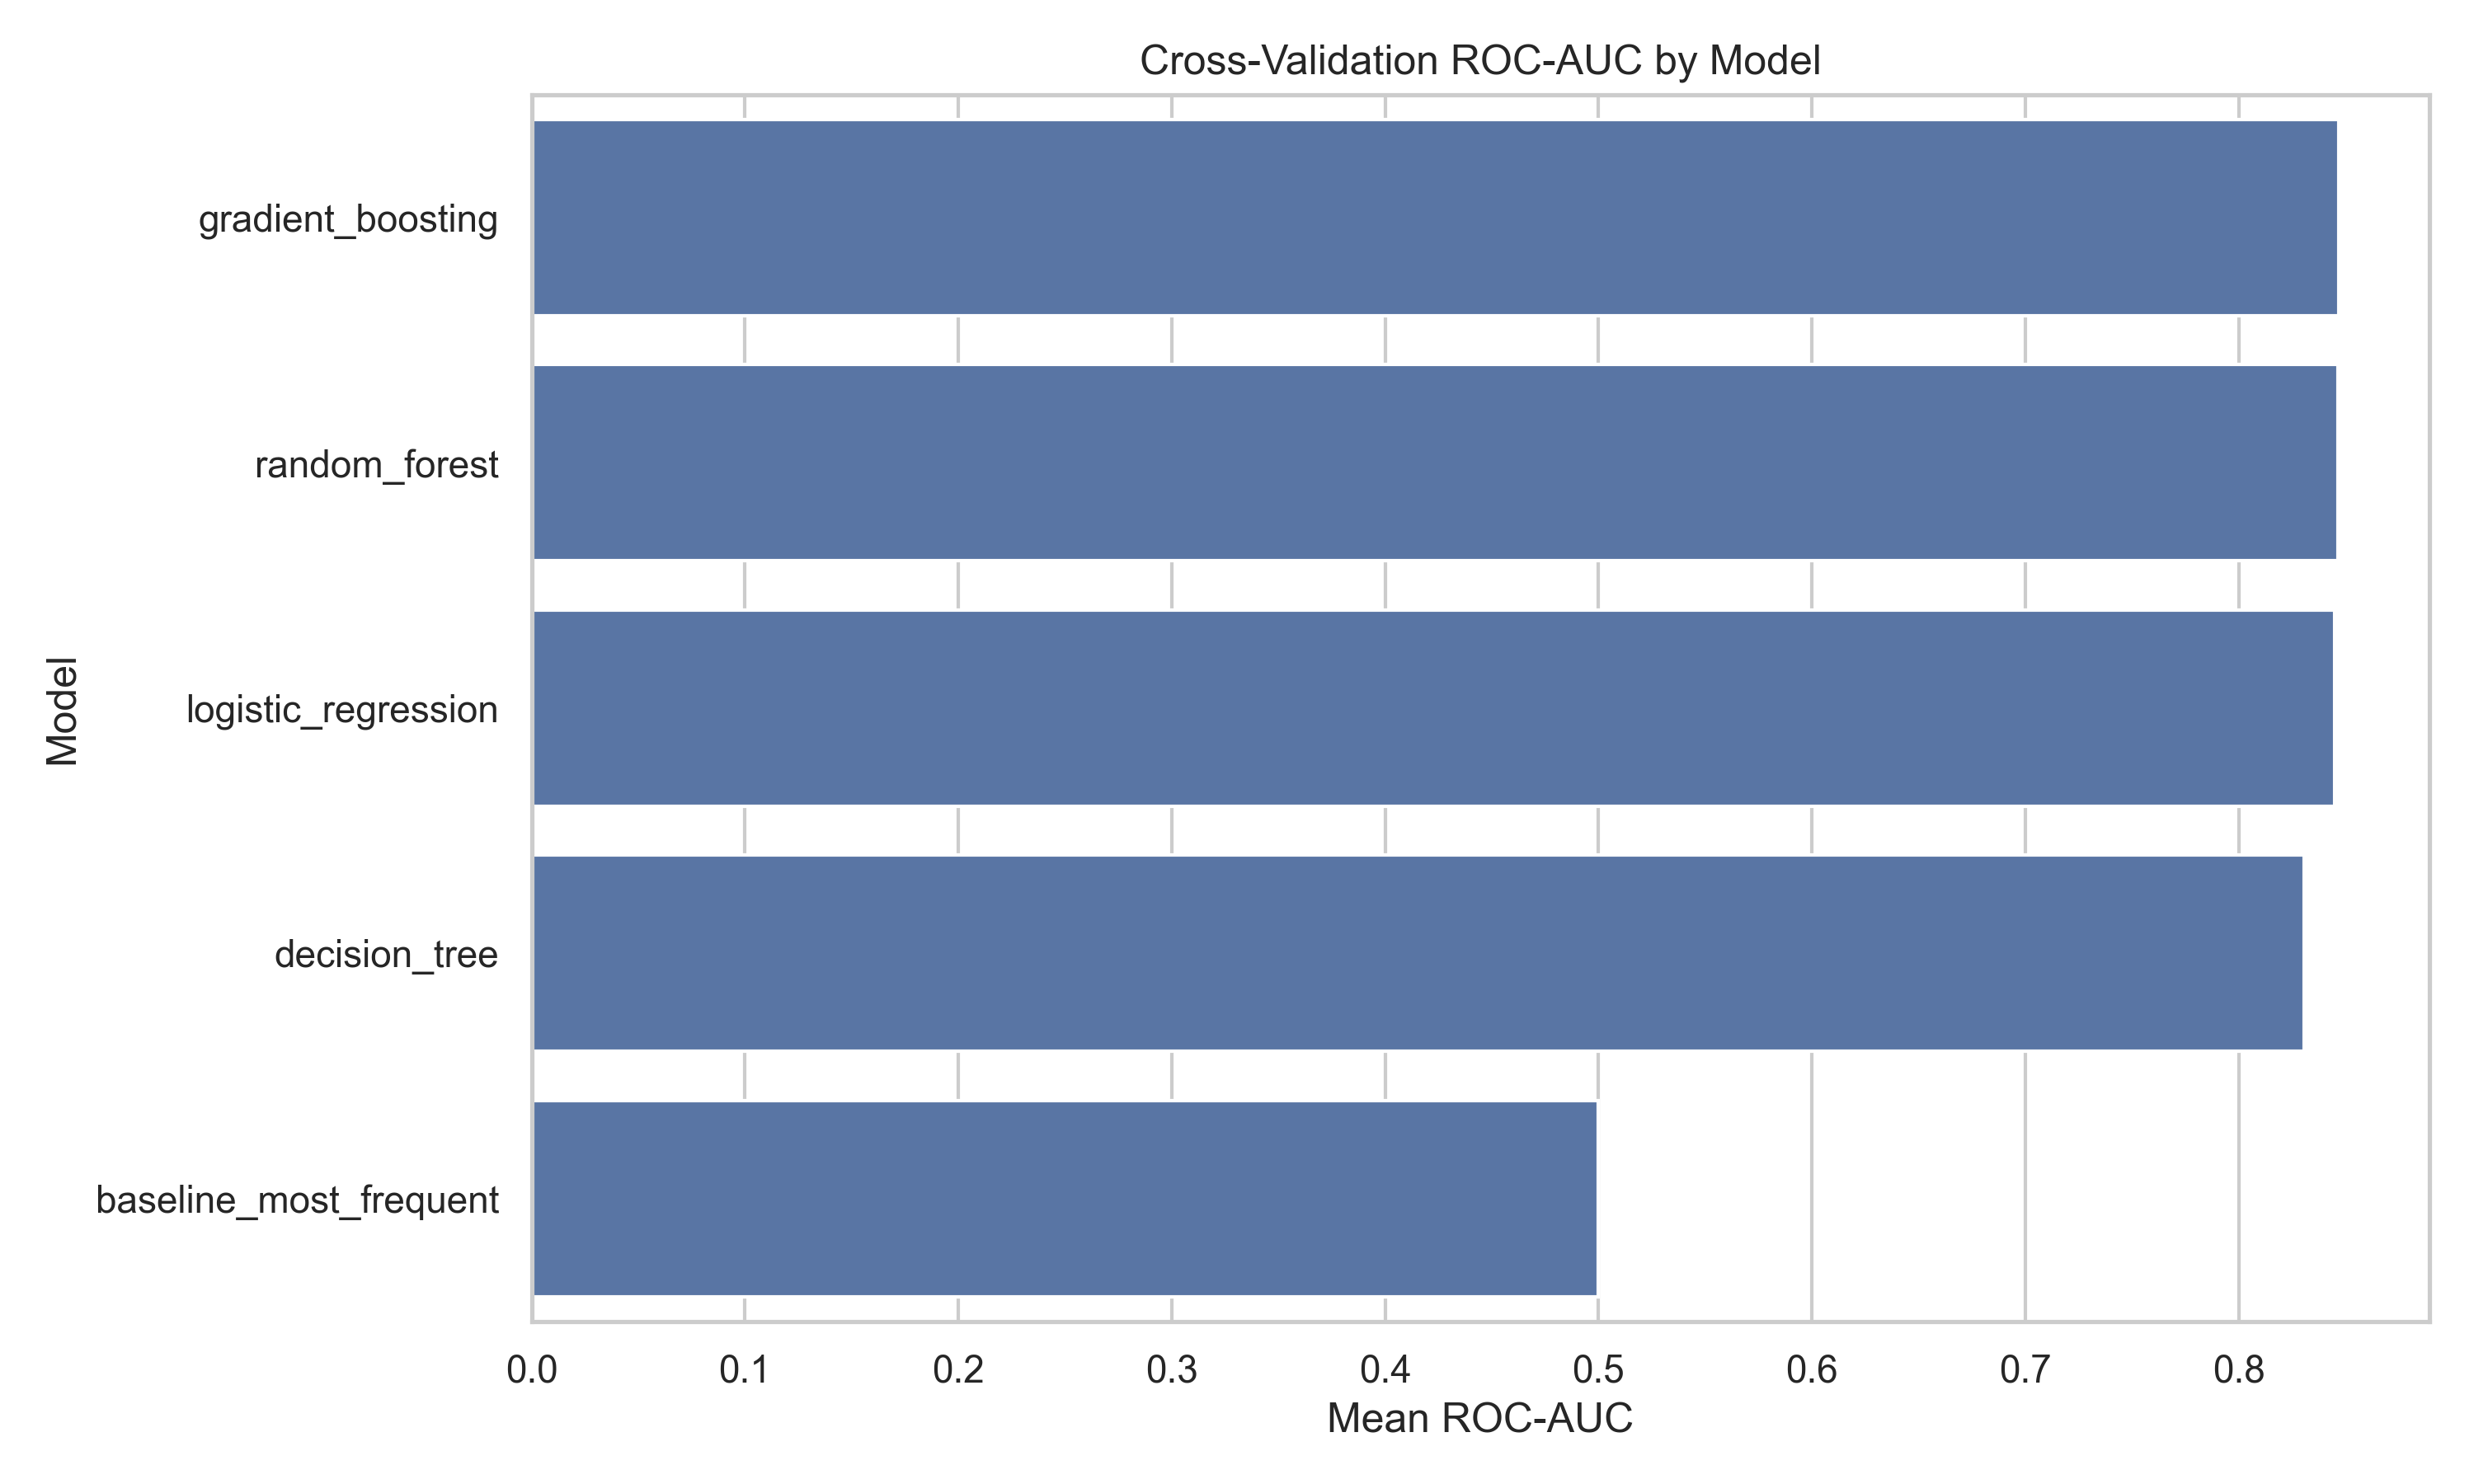

In [8]:
display(Image(filename=FIGURES_DIR / "cross_validation_roc_auc_by_model.png"))

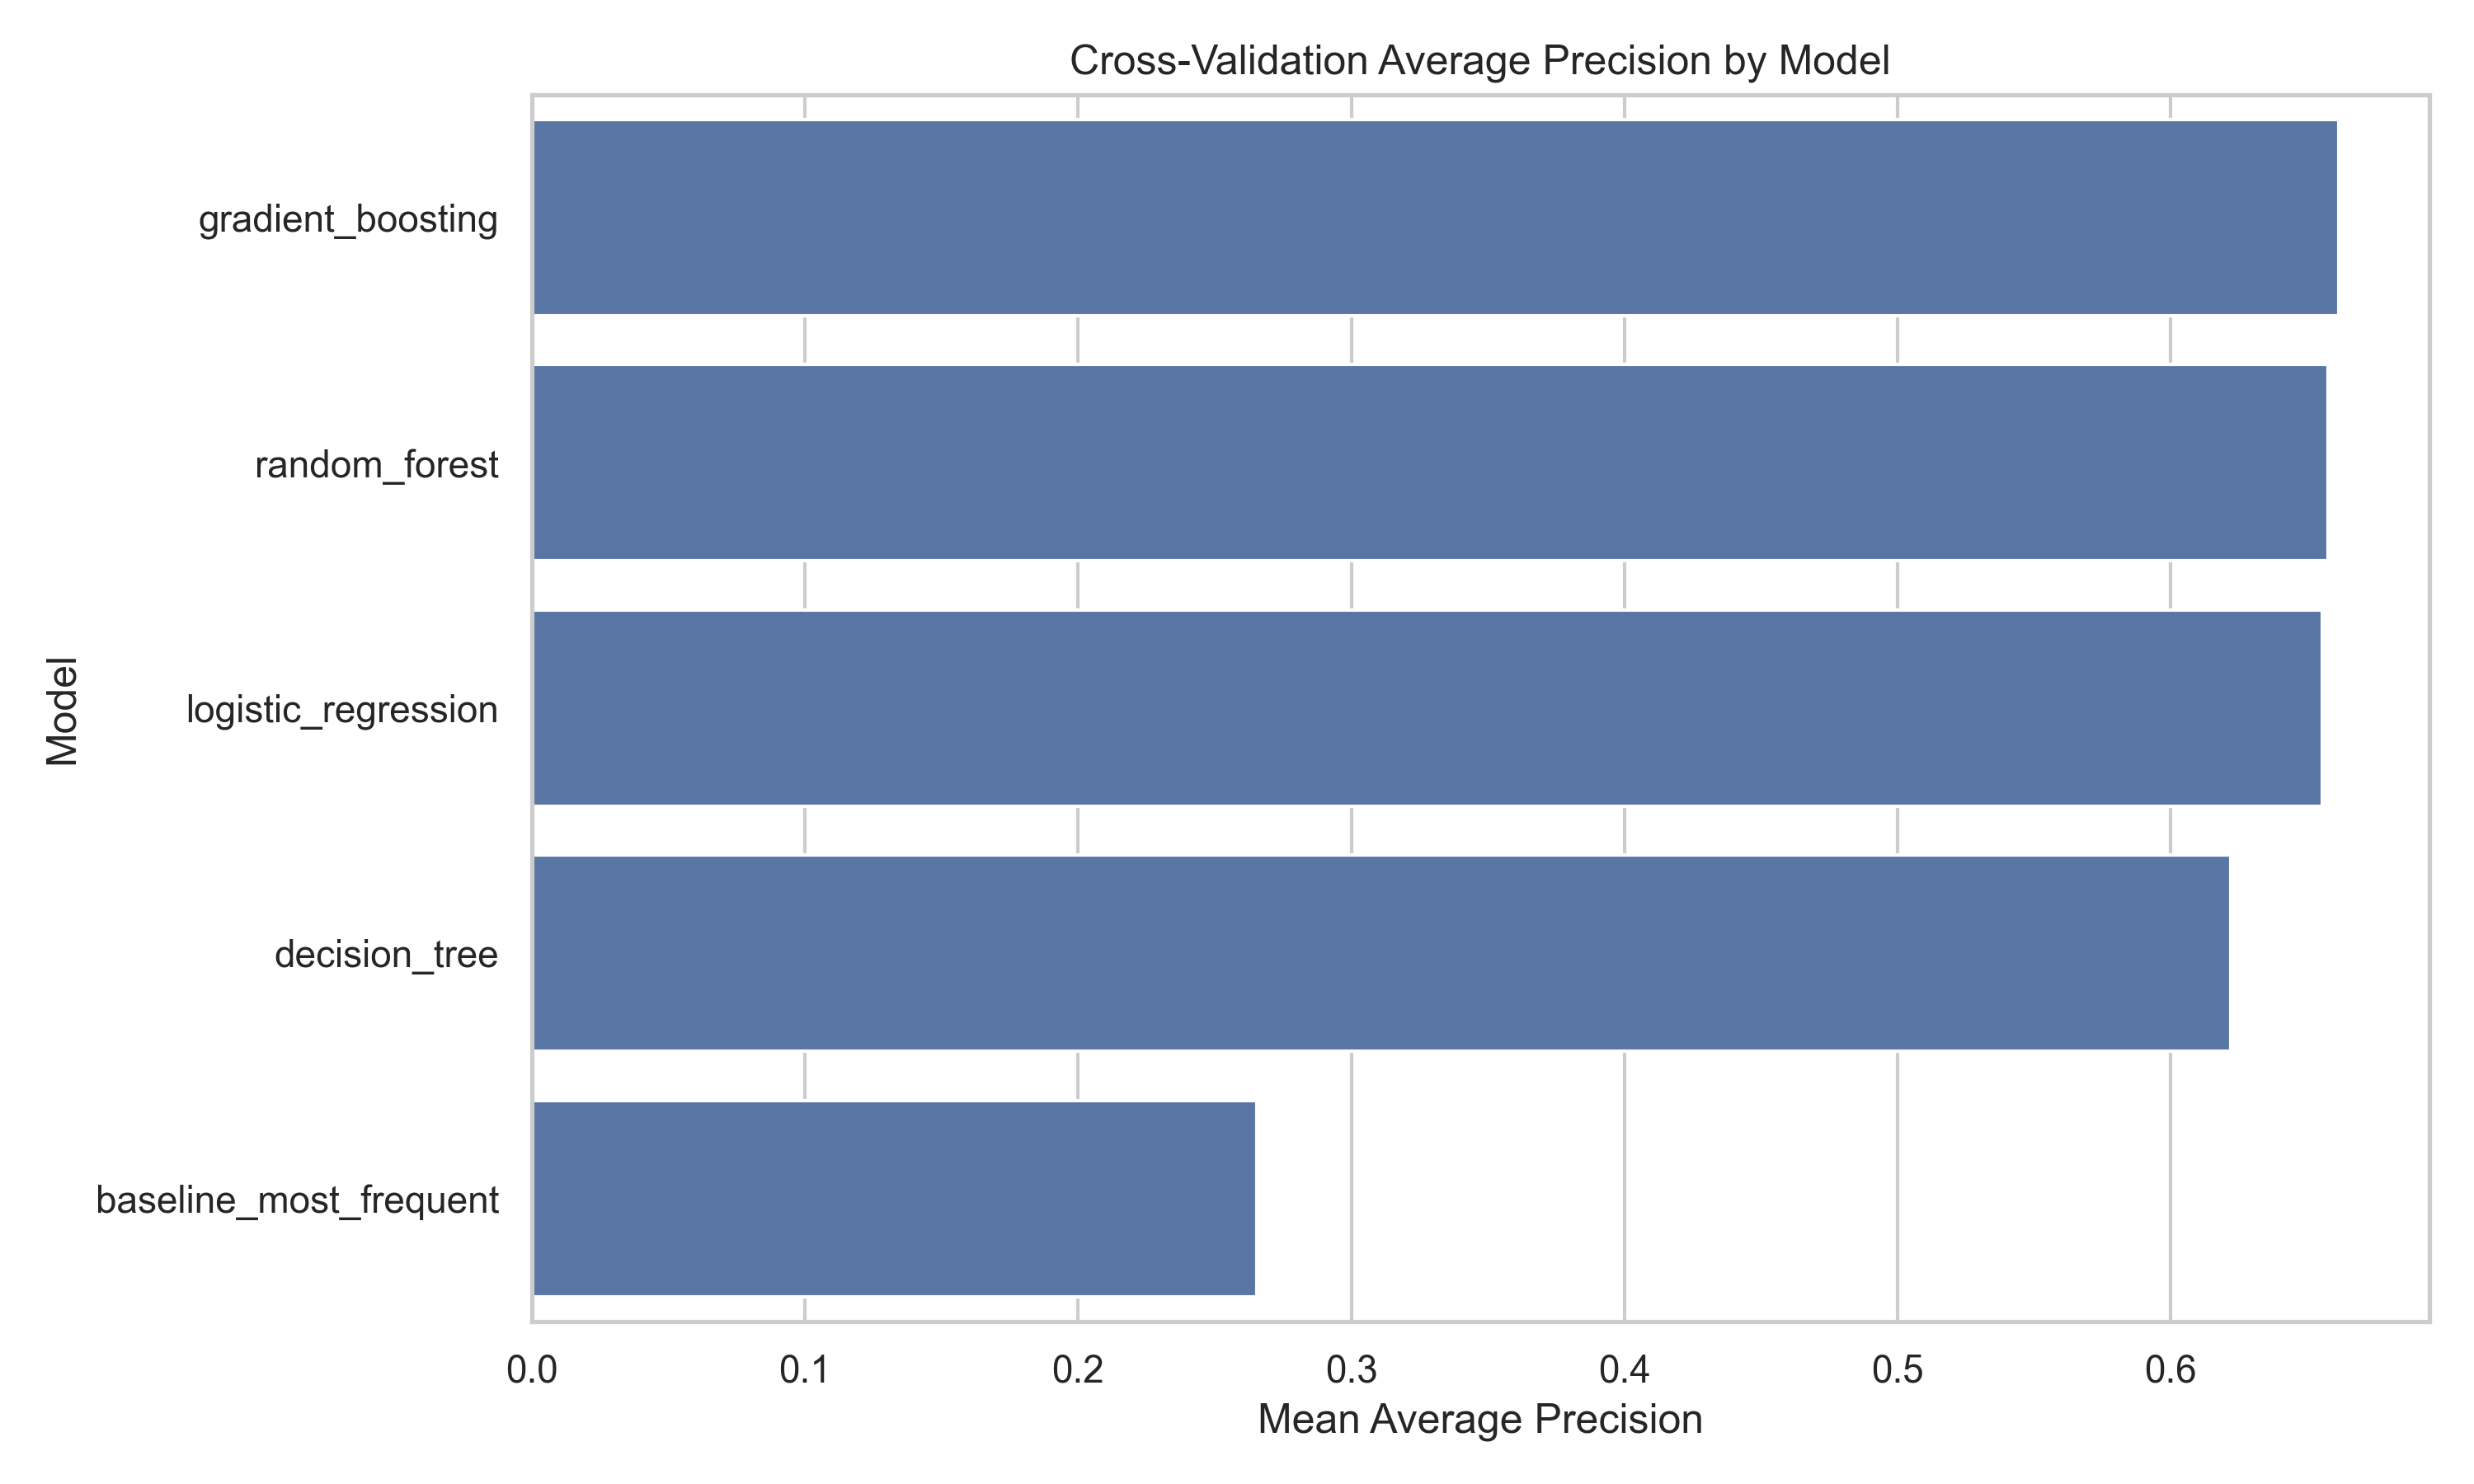

In [9]:
display(Image(filename=FIGURES_DIR / "cross_validation_average_precision_by_model.png"))

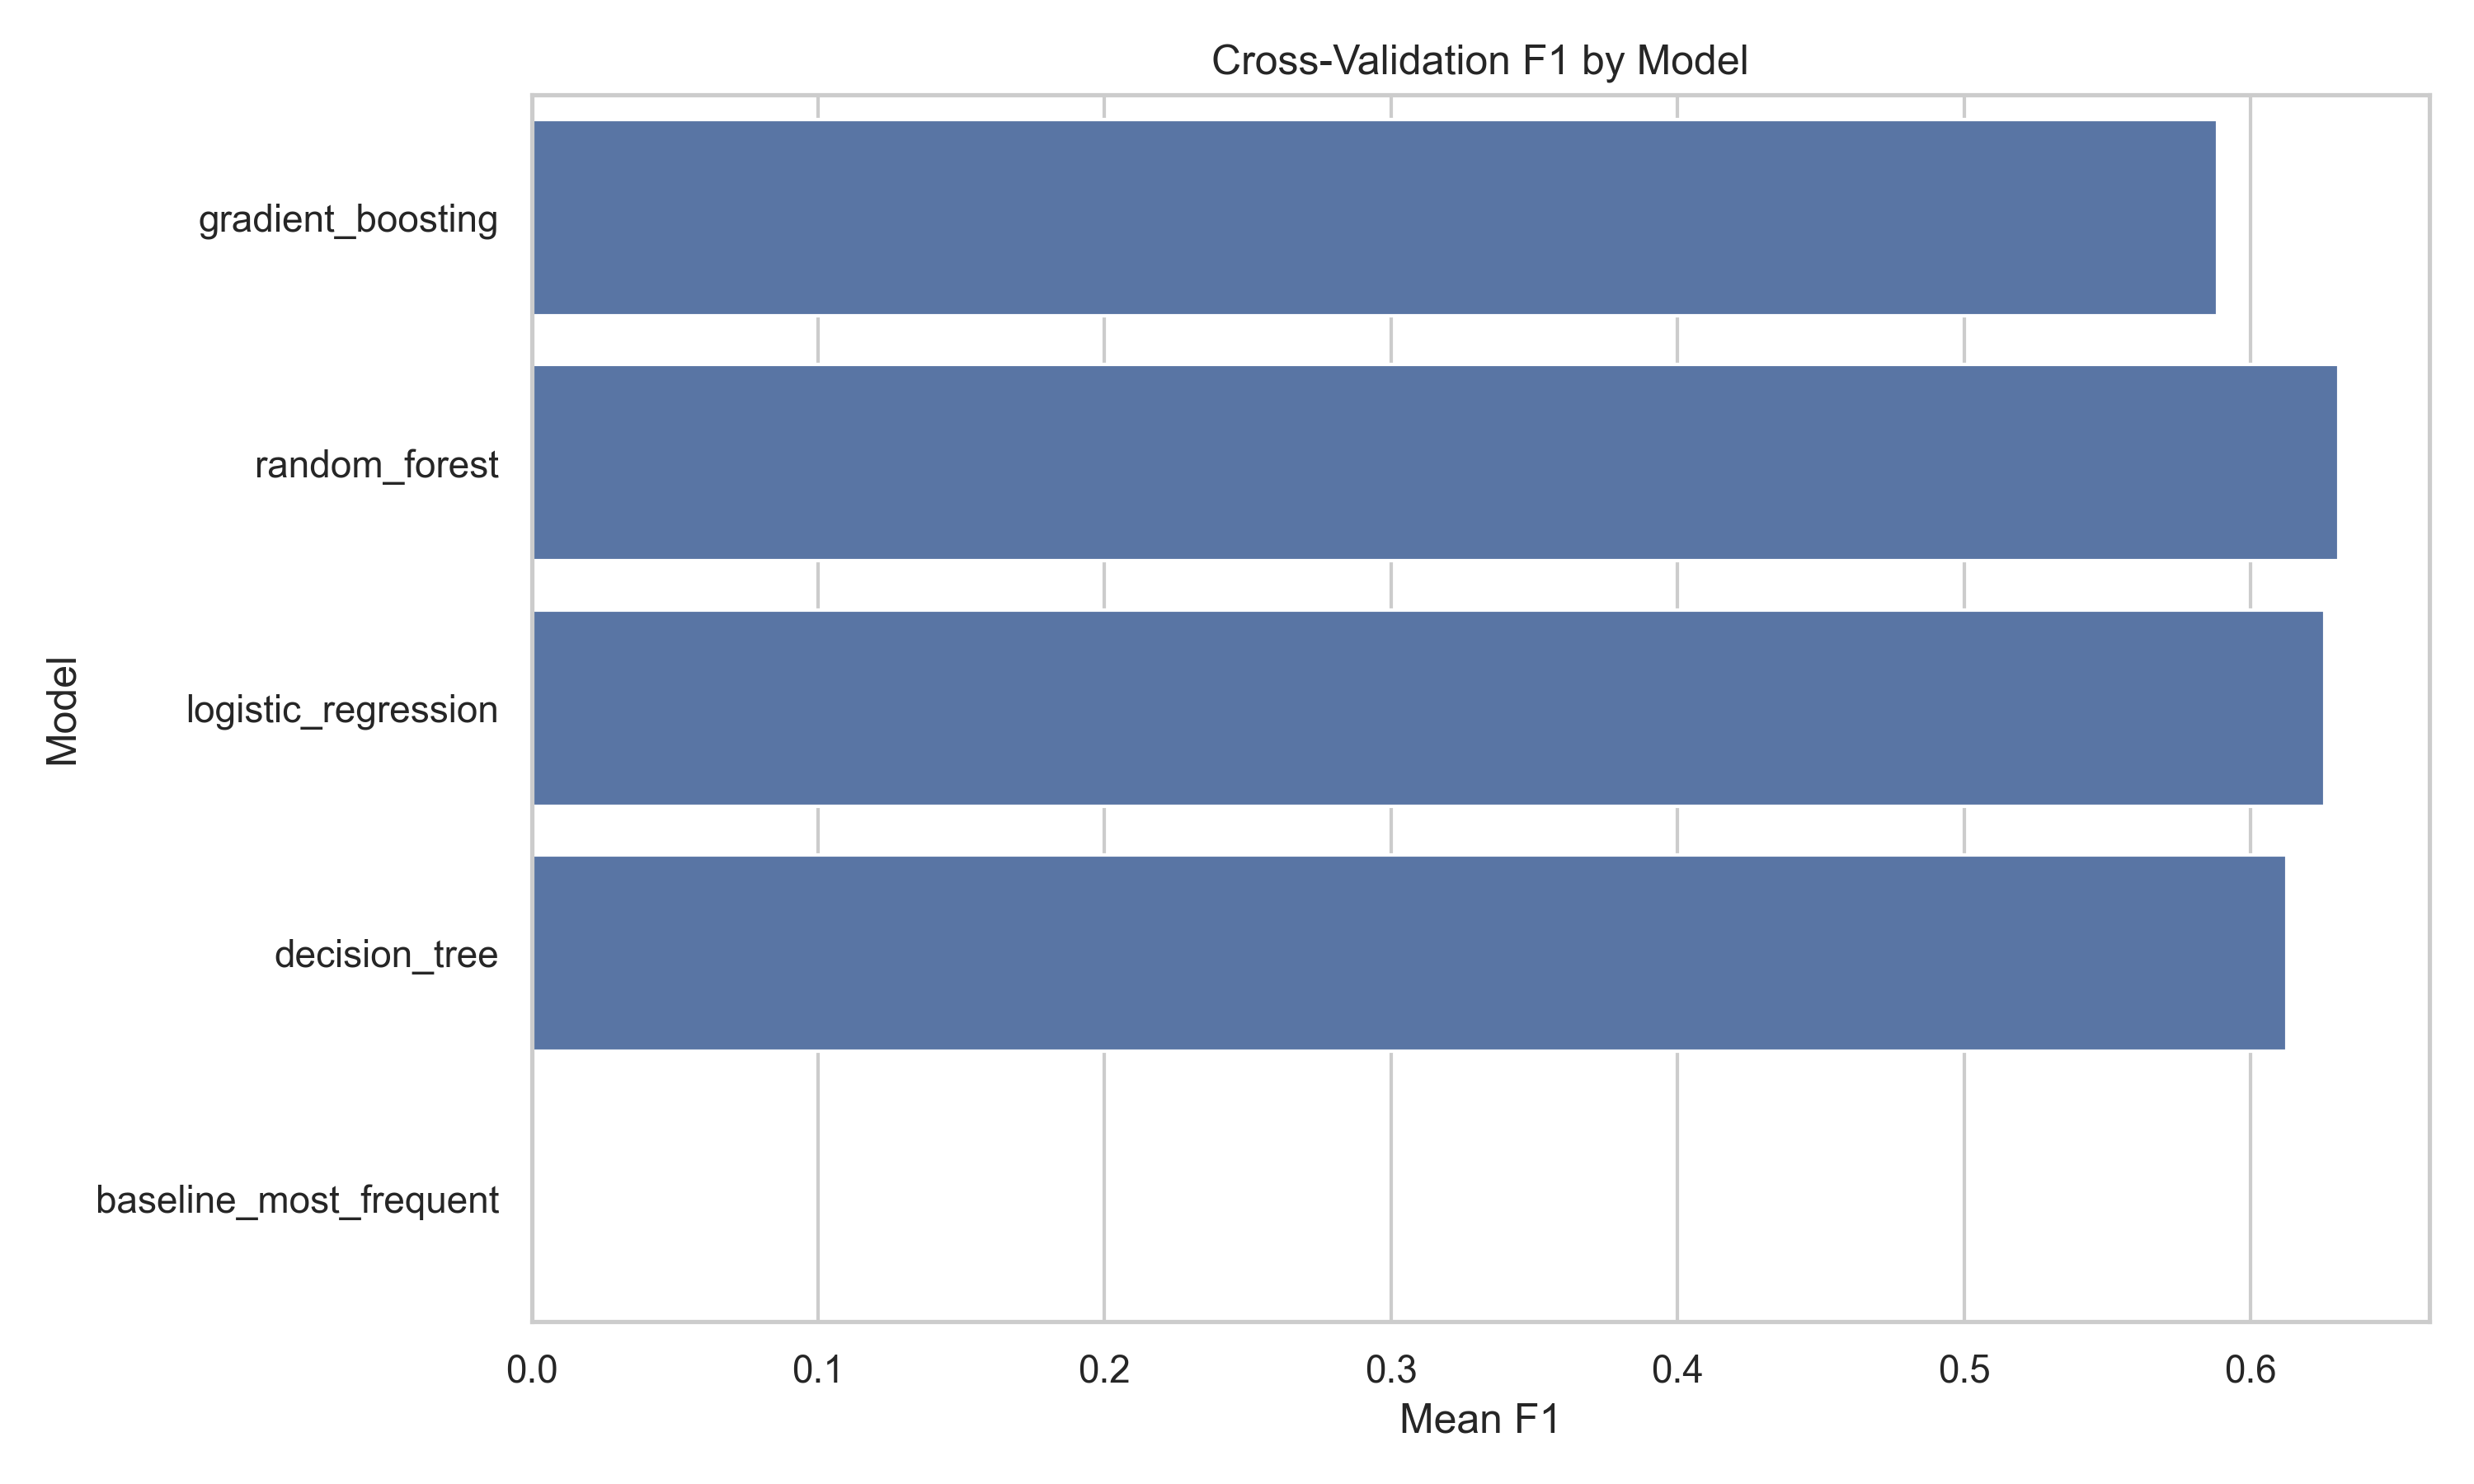

In [10]:
display(Image(filename=FIGURES_DIR / "cross_validation_f1_by_model.png"))

## Cross-Validation Results

Cross-validation confirms that Gradient Boosting is the strongest model for ranking churn risk.

It achieved the highest mean ROC-AUC and Average Precision across folds. This supports using Gradient Boosting as the final predictive model.

The baseline model has acceptable-looking accuracy because most customers do not churn, but it has zero recall and is useless for retention.

In [12]:
final_model_evaluation

,model,threshold_name,threshold,accuracy,precision,recall,f1,roc_auc,average_precision,true_negatives,false_positives,false_negatives,true_positives,customers_flagged,churners_captured,churners_missed
0,gradient_boosting,default_0_50,0.5000,0.8048,0.6689,0.5241,0.5877,0.8442,0.6631,938,97,178,196,293,196,178
1,gradient_boosting,balanced_f1,0.2400,0.7466,0.5143,0.8182,0.6316,0.8442,0.6631,746,289,68,306,595,306,68


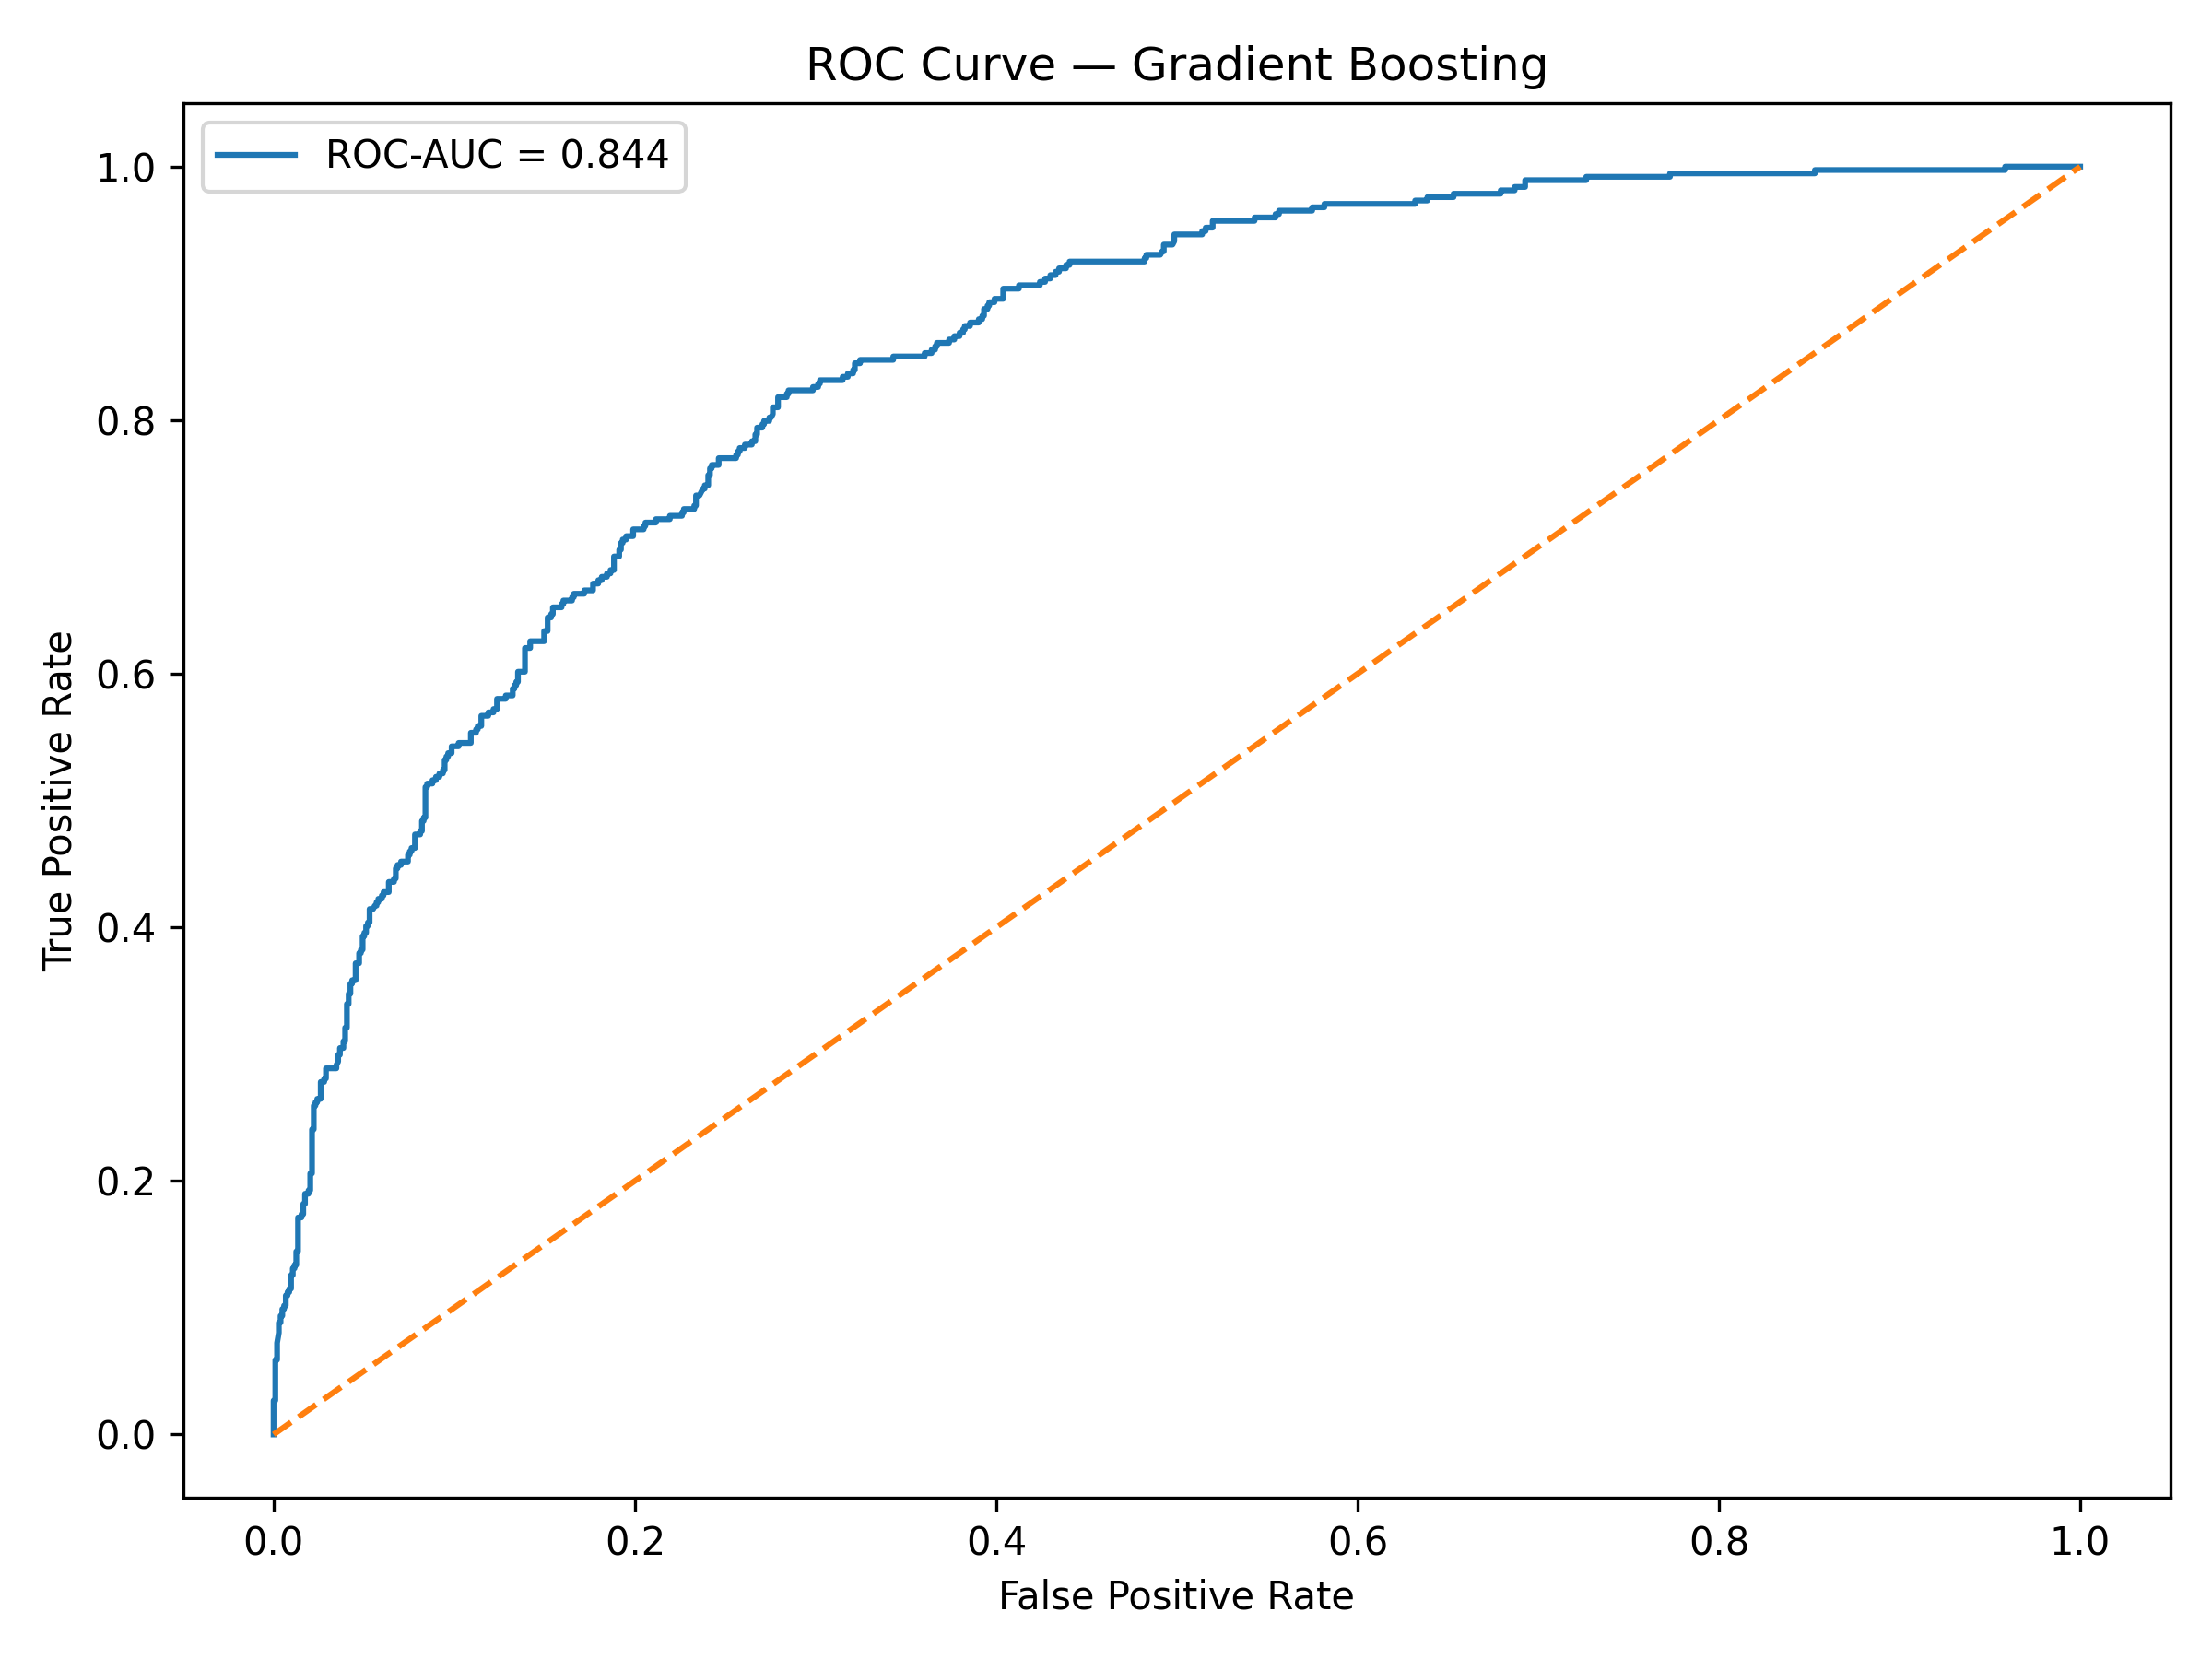

In [13]:
display(Image(filename=FIGURES_DIR / "roc_curve_gradient_boosting.png"))

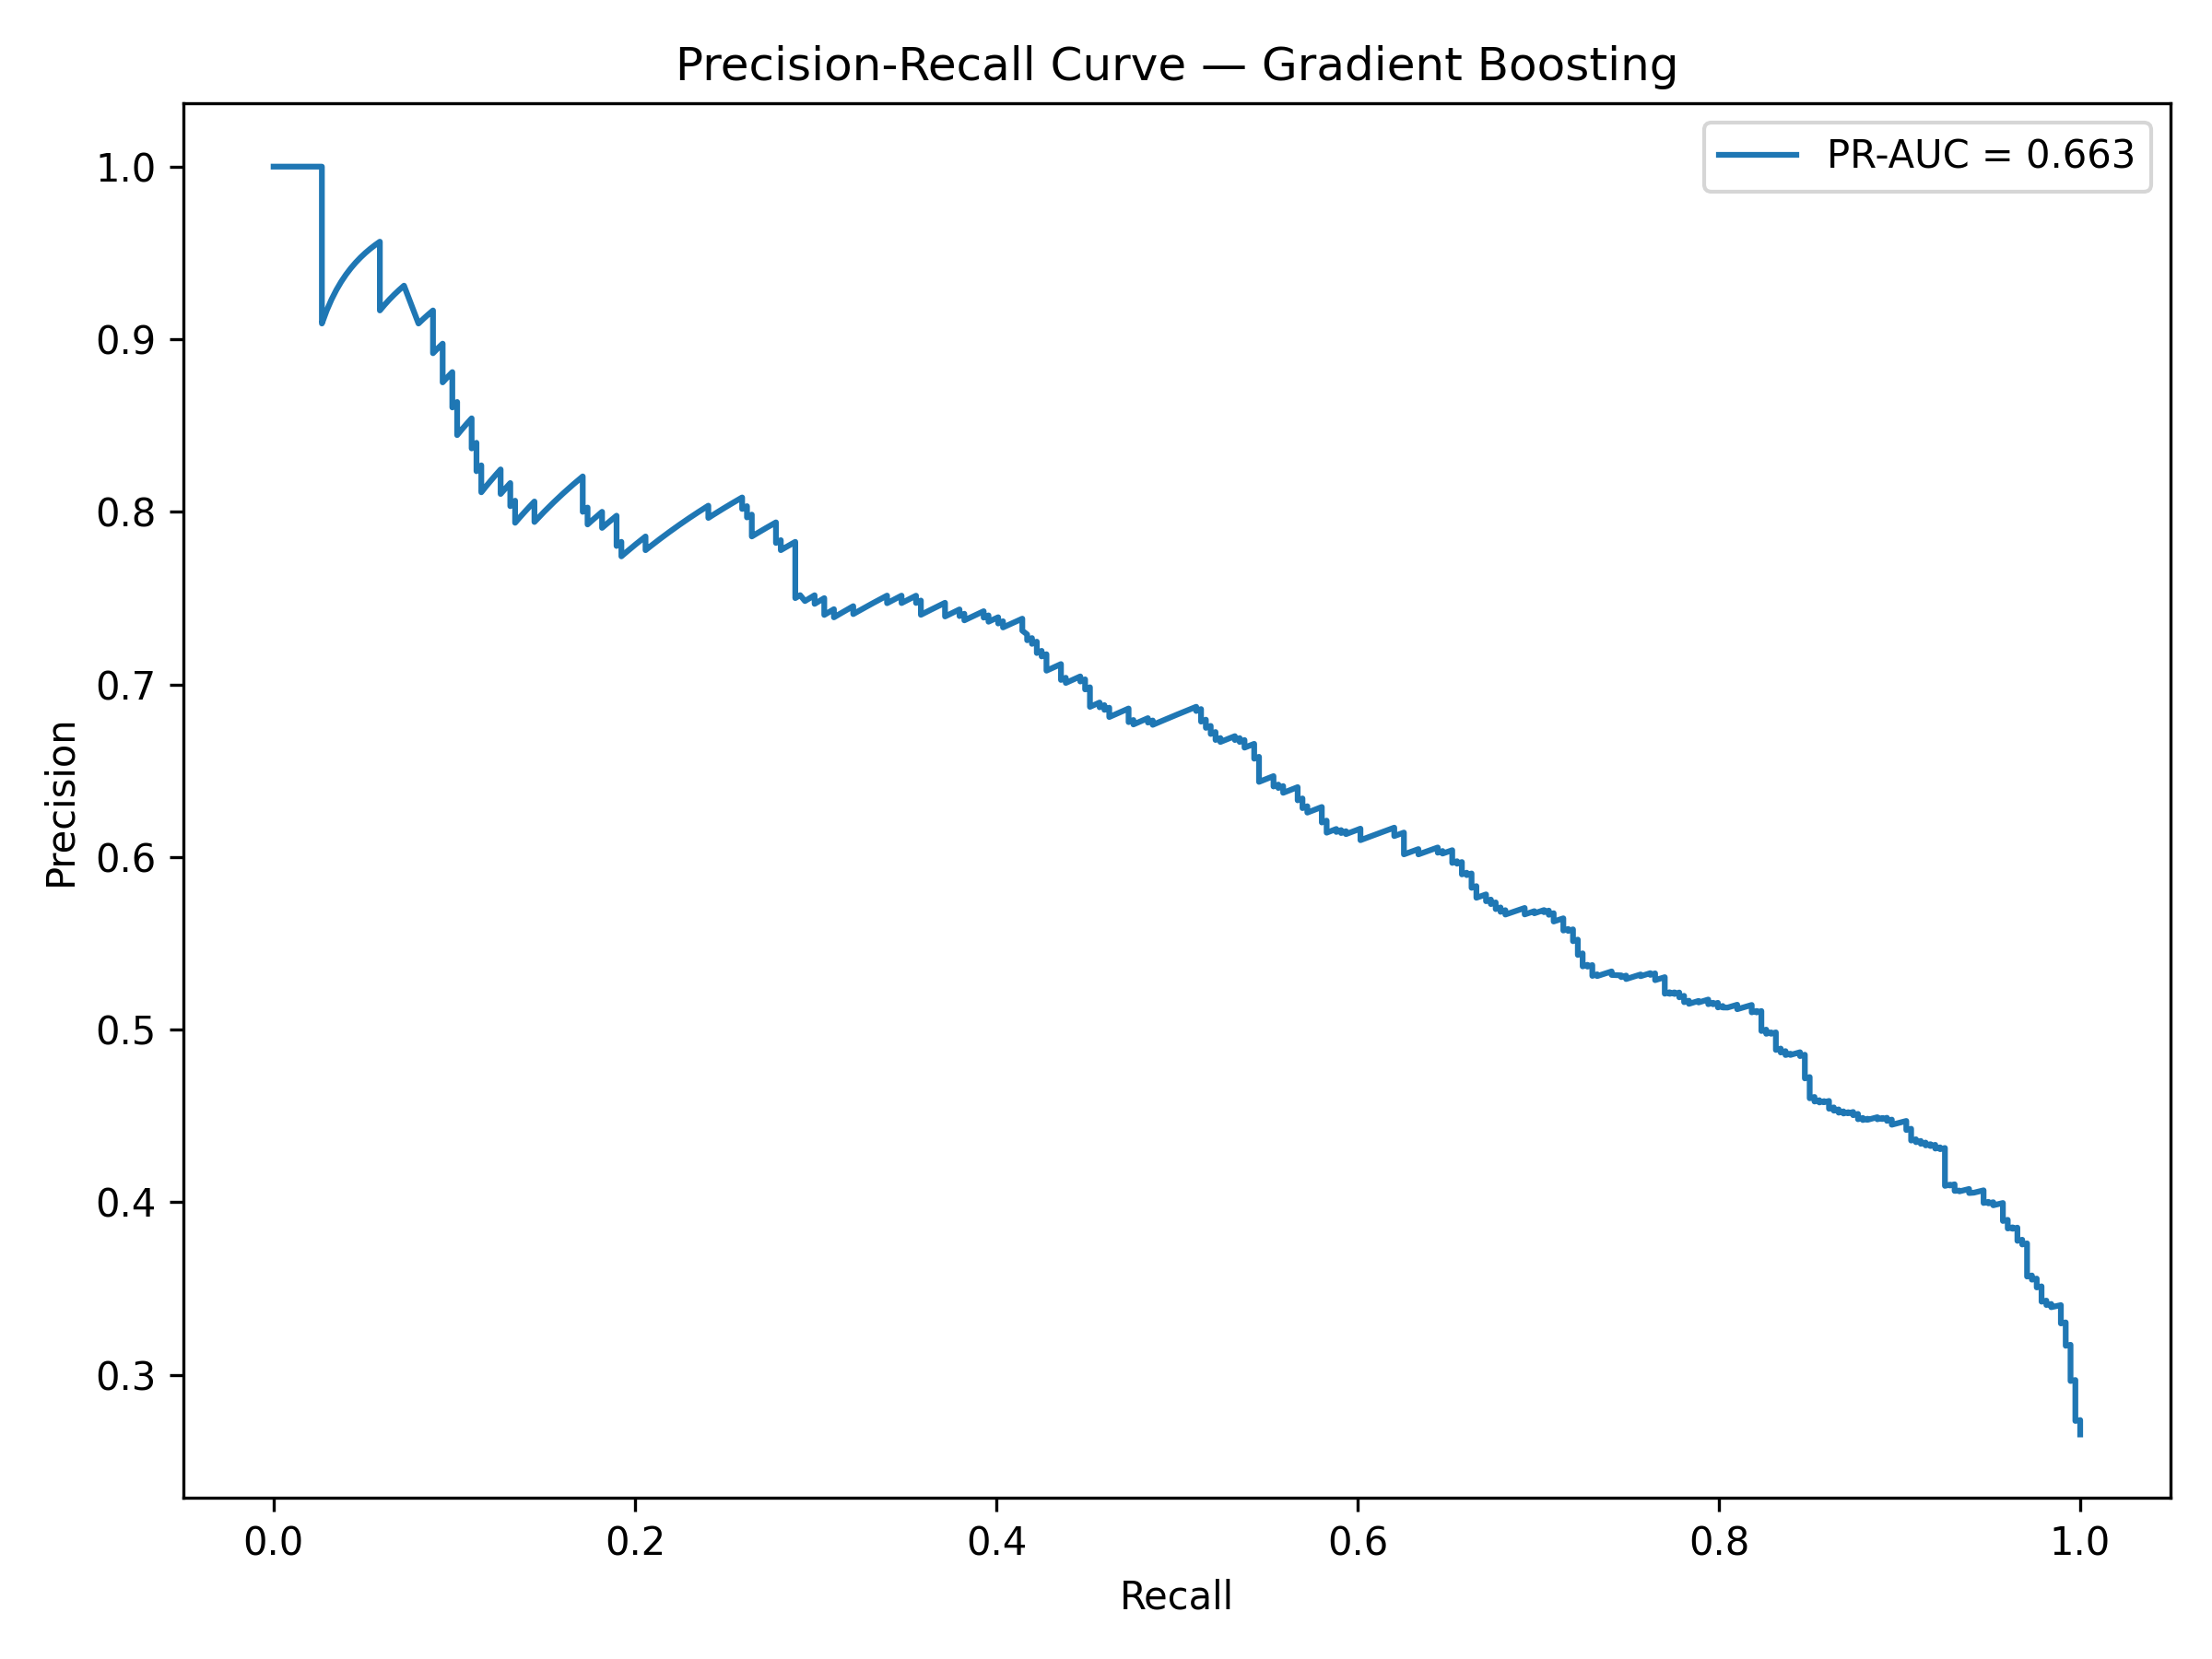

In [14]:
display(Image(filename=FIGURES_DIR / "precision_recall_curve_gradient_boosting.png"))

## Final Model Evaluation

The selected model is Gradient Boosting.

The model achieved strong separation performance with ROC-AUC around 0.844 and Average Precision around 0.663.

However, probability ranking is only part of the decision. The final business impact depends on the classification threshold.

In [15]:
threshold_recommendation[
    [
        "strategy",
        "threshold",
        "precision",
        "recall",
        "f1",
        "false_positives",
        "false_negatives",
        "customers_flagged",
        "churners_captured",
        "churners_missed",
        "business_meaning",
    ]
]

,strategy,threshold,precision,recall,f1,false_positives,false_negatives,customers_flagged,churners_captured,churners_missed,business_meaning
0,balanced_f1,0.2400,0.5143,0.8182,0.6316,289,68,595,306,68,Best balance between precision and recall.
1,retention_recall,0.2900,0.5306,0.7647,0.6265,253,88,539,286,88,"Prioritizes capturing churners, accepting more..."
2,efficient_precision,0.5500,0.7046,0.4465,0.5466,70,207,237,167,207,Prioritizes contacting fewer customers with hi...


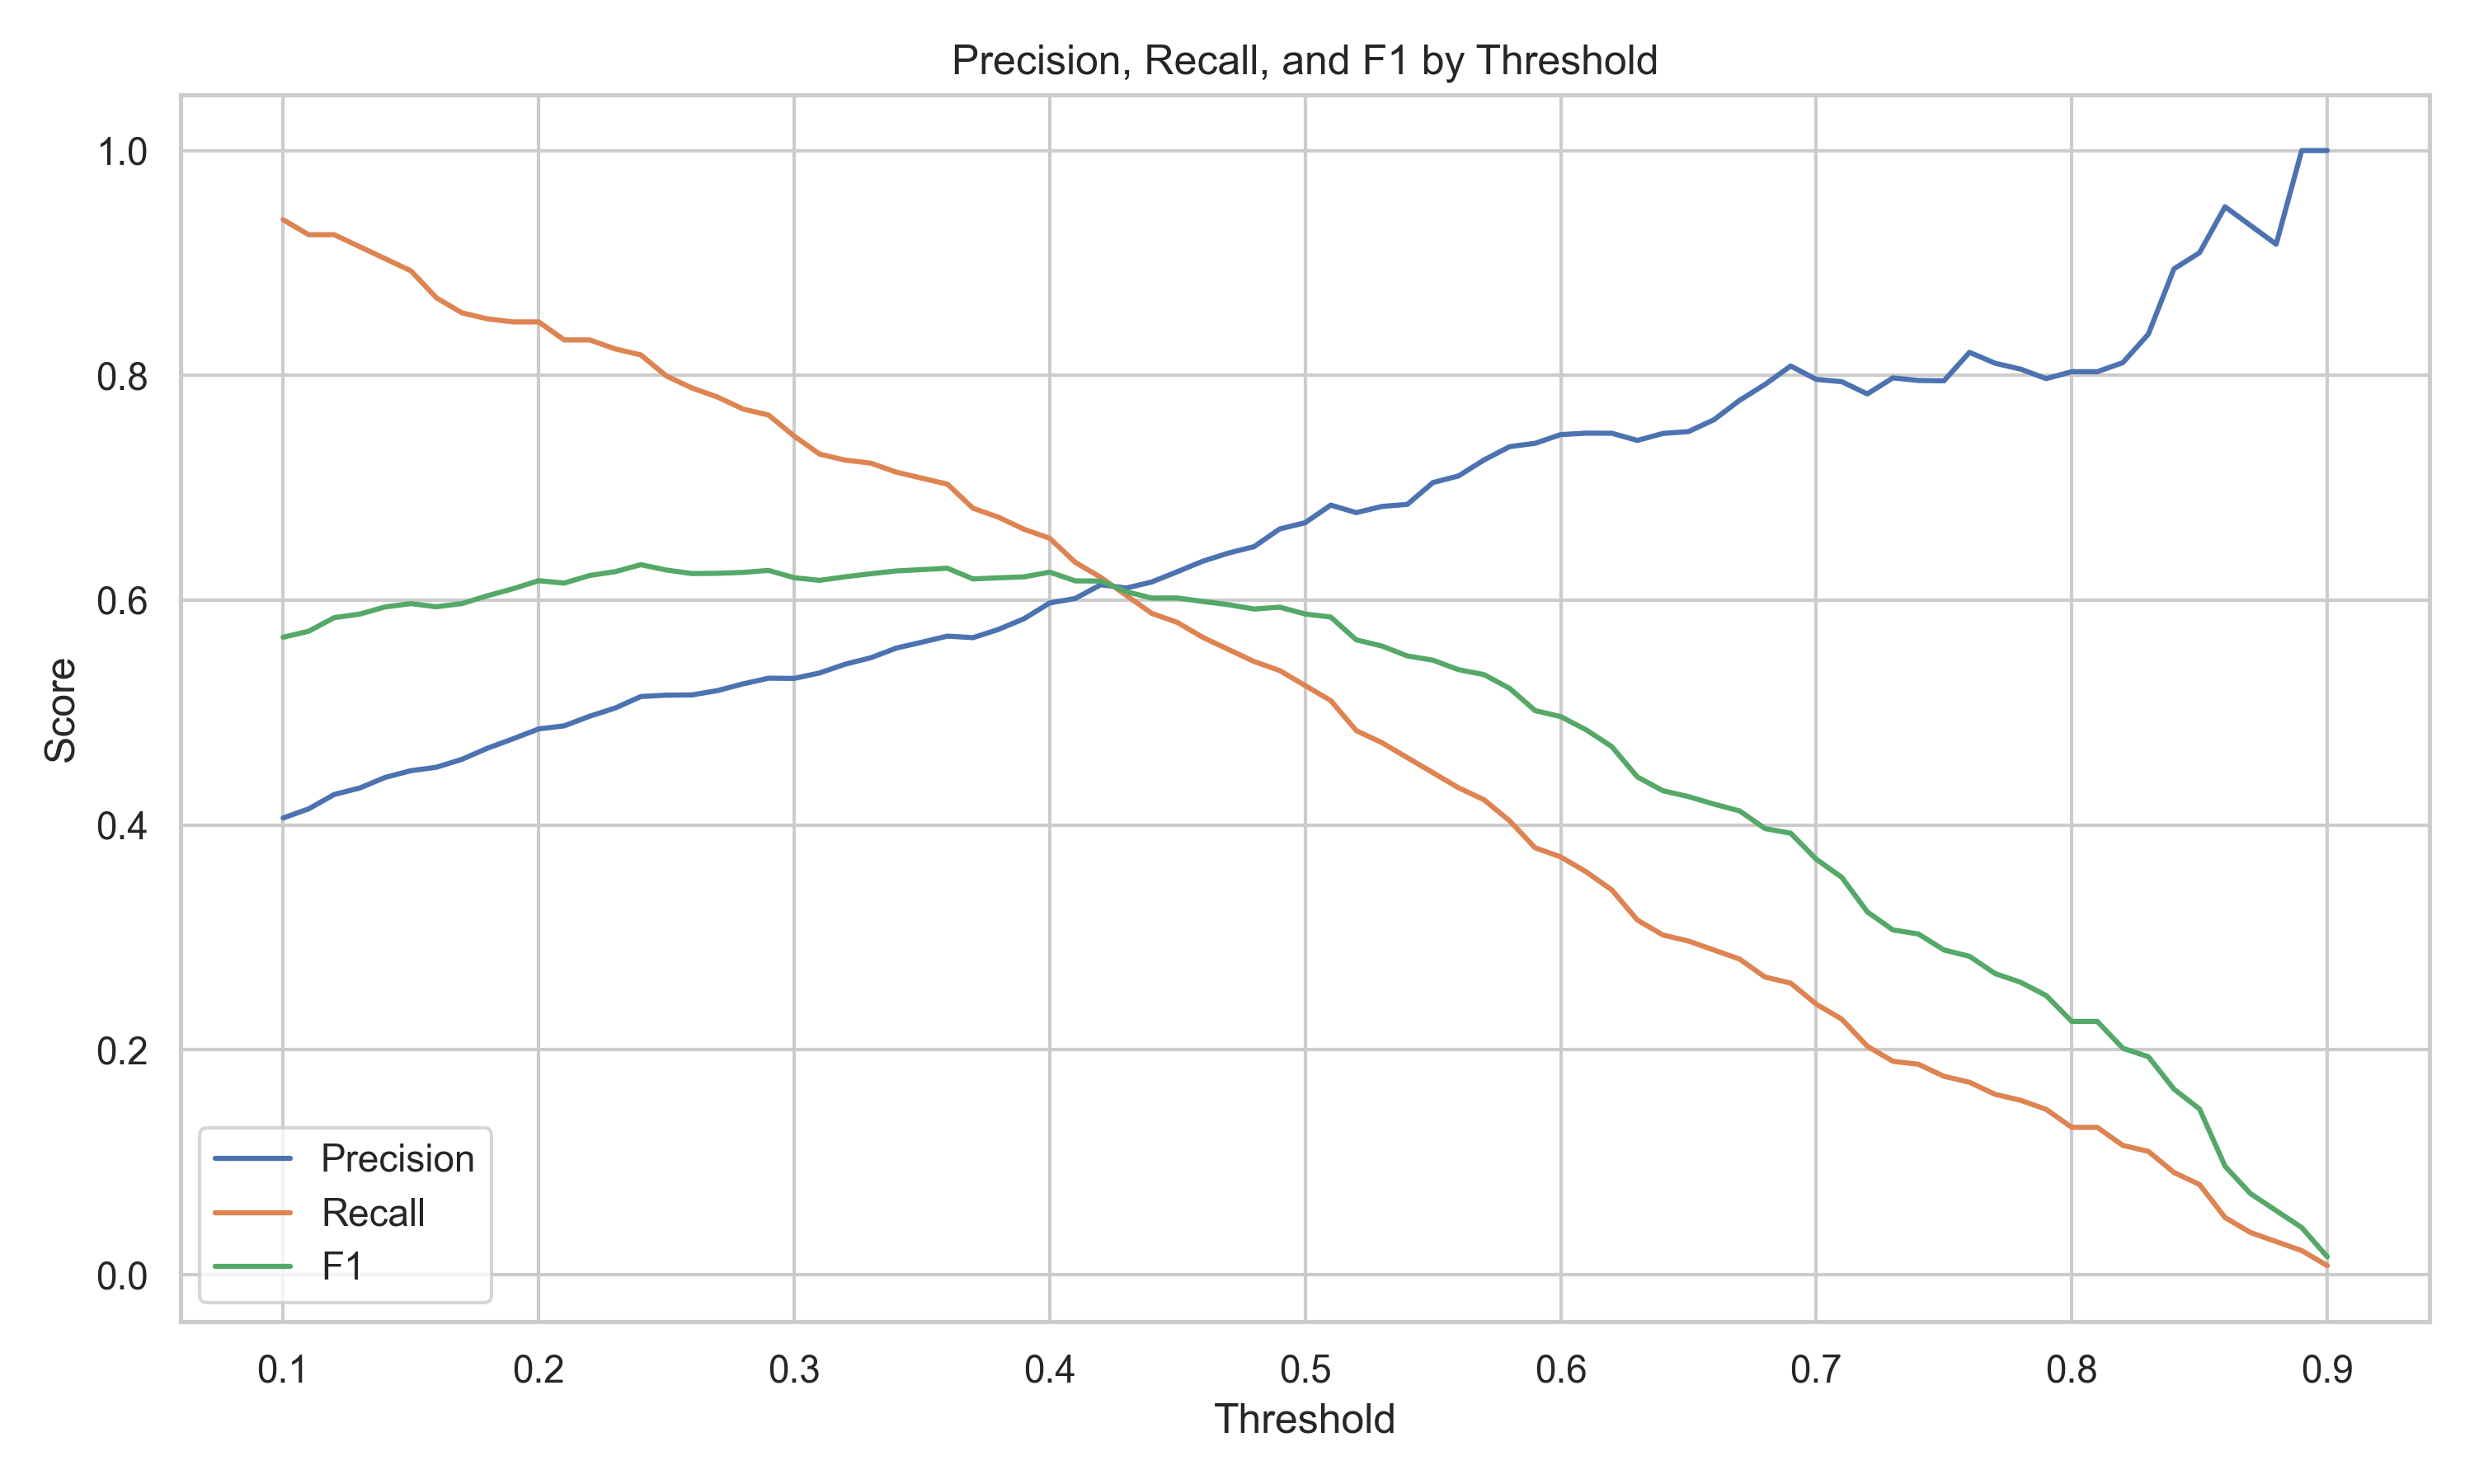

In [16]:
display(Image(filename=FIGURES_DIR / "threshold_precision_recall_f1.png"))

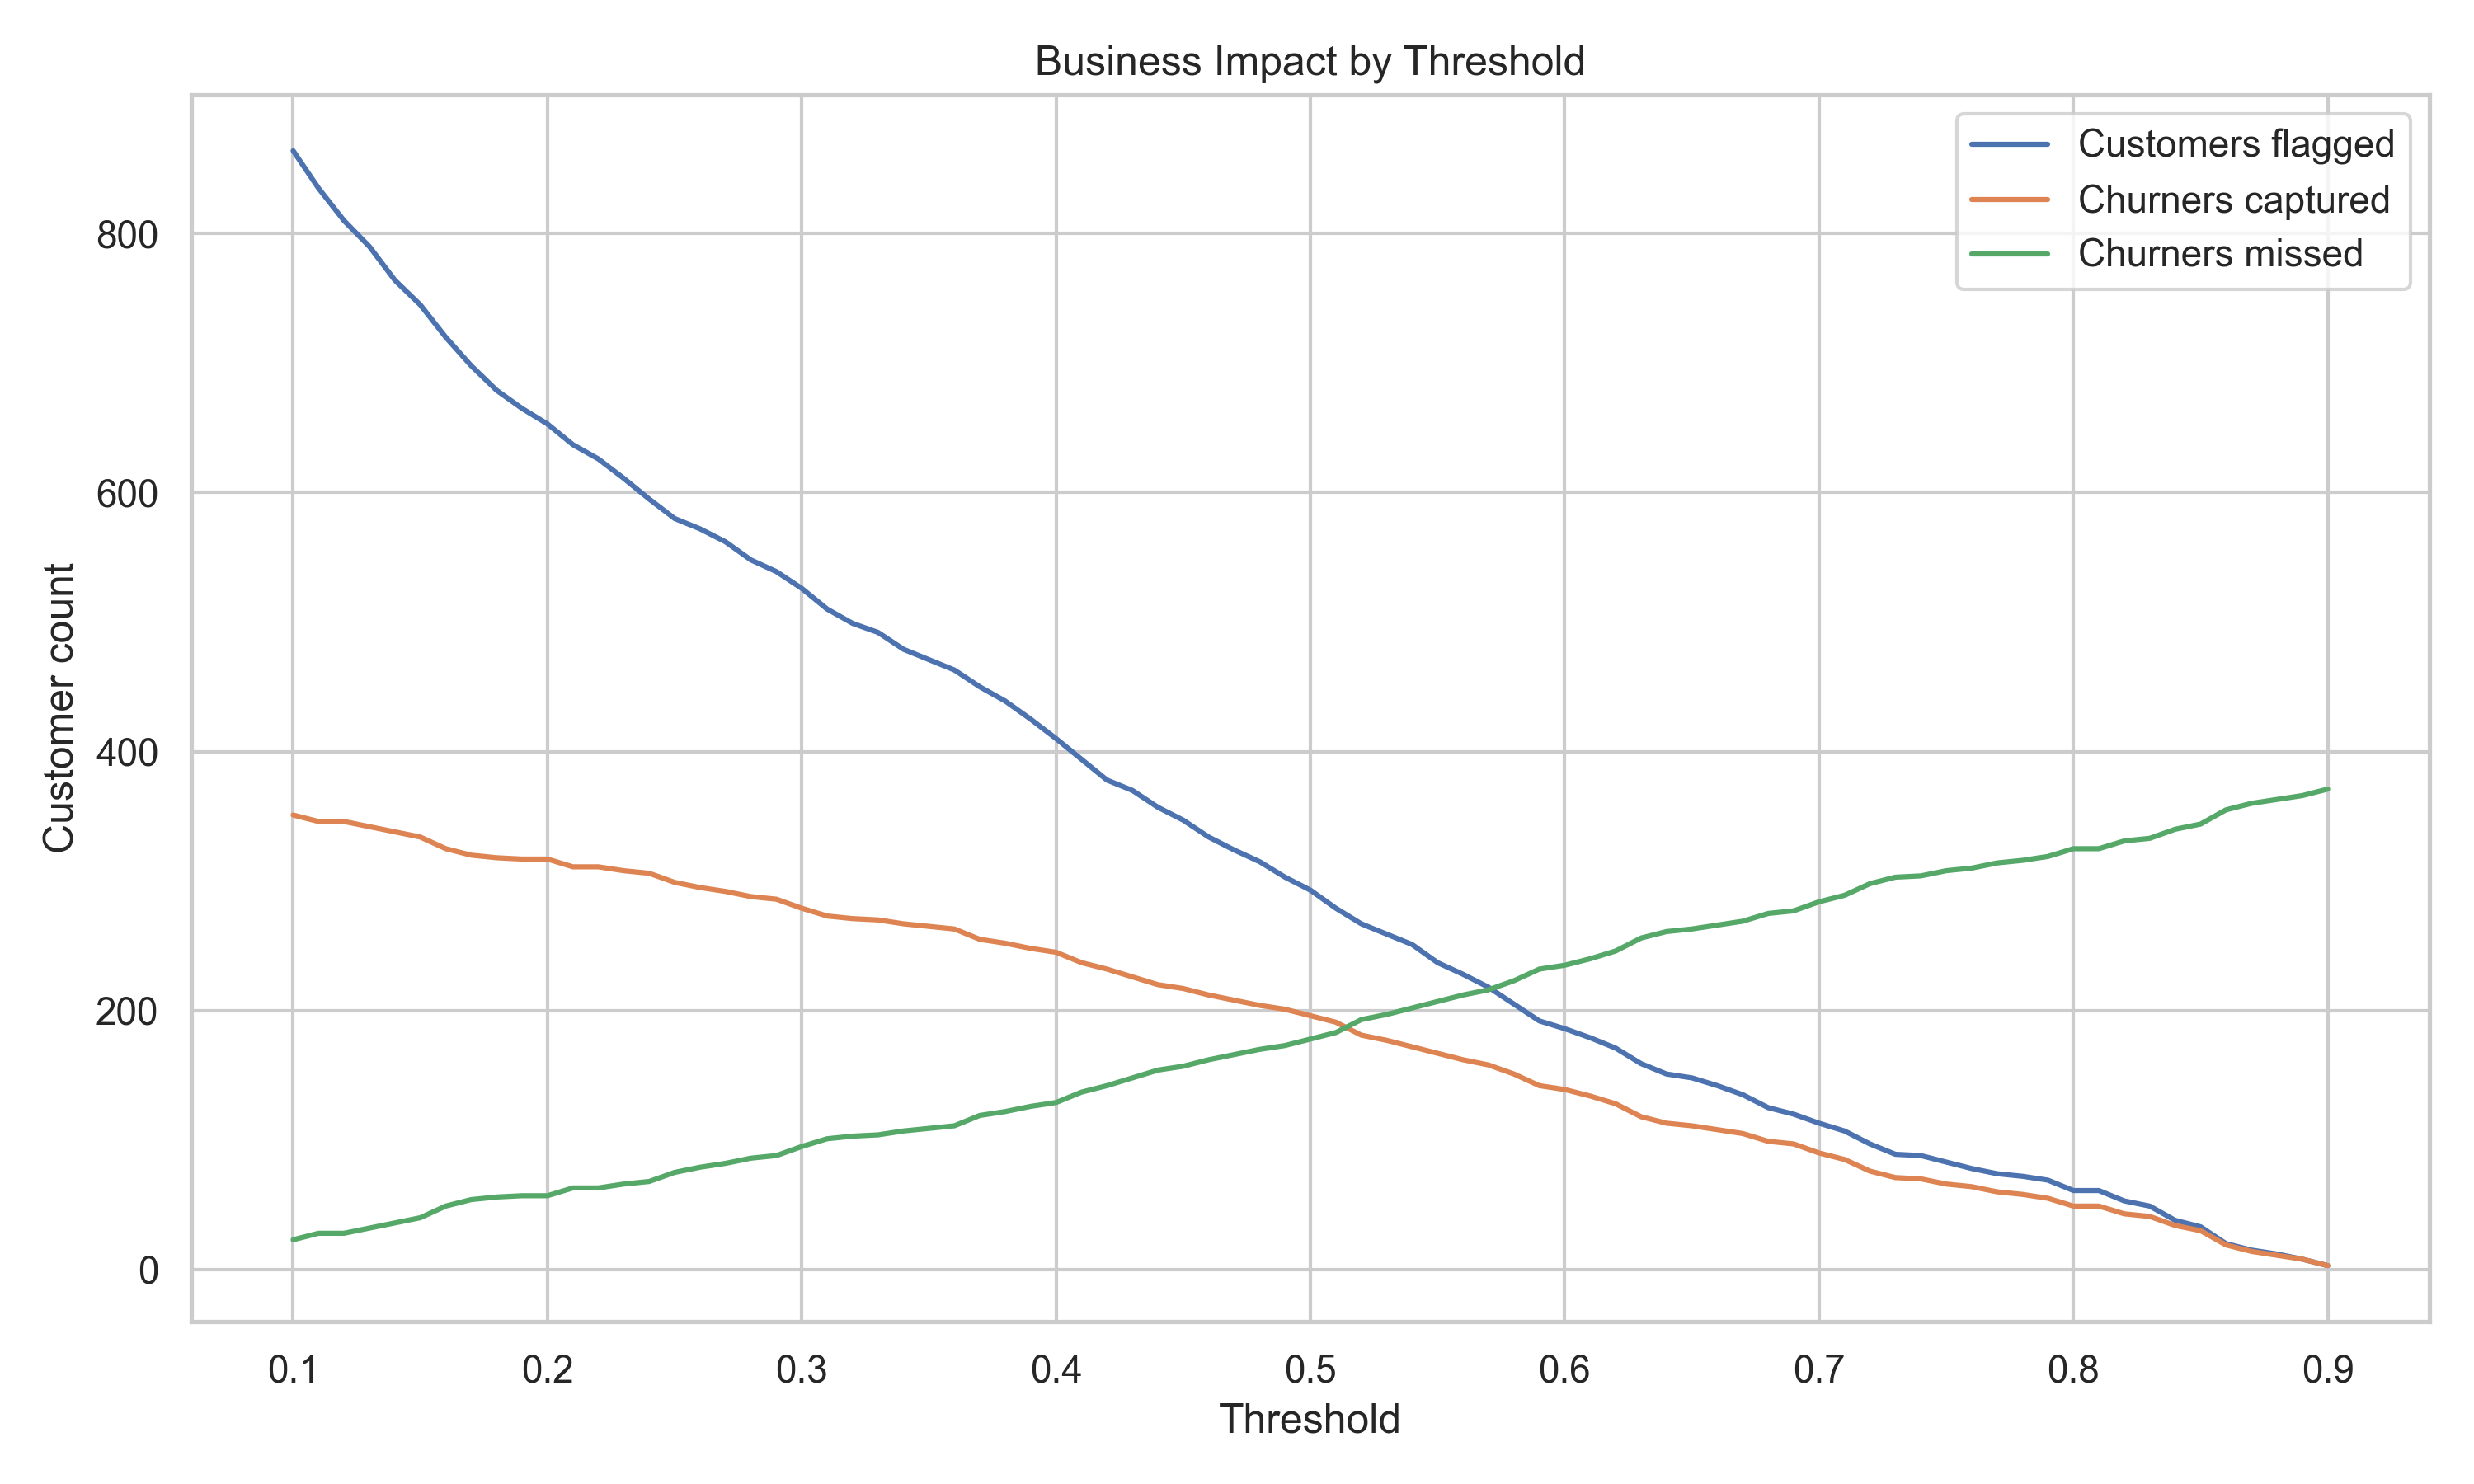

In [17]:
display(Image(filename=FIGURES_DIR / "threshold_business_impact.png"))

## Threshold Analysis

The default threshold of 0.50 is not the best option for retention.

At threshold 0.50, the model captures 196 churners and misses 178.

At threshold 0.24, the model captures 306 churners and misses only 68.

The trade-off is that the lower threshold flags more customers for retention actions. This increases false positives, but it substantially reduces missed churners.

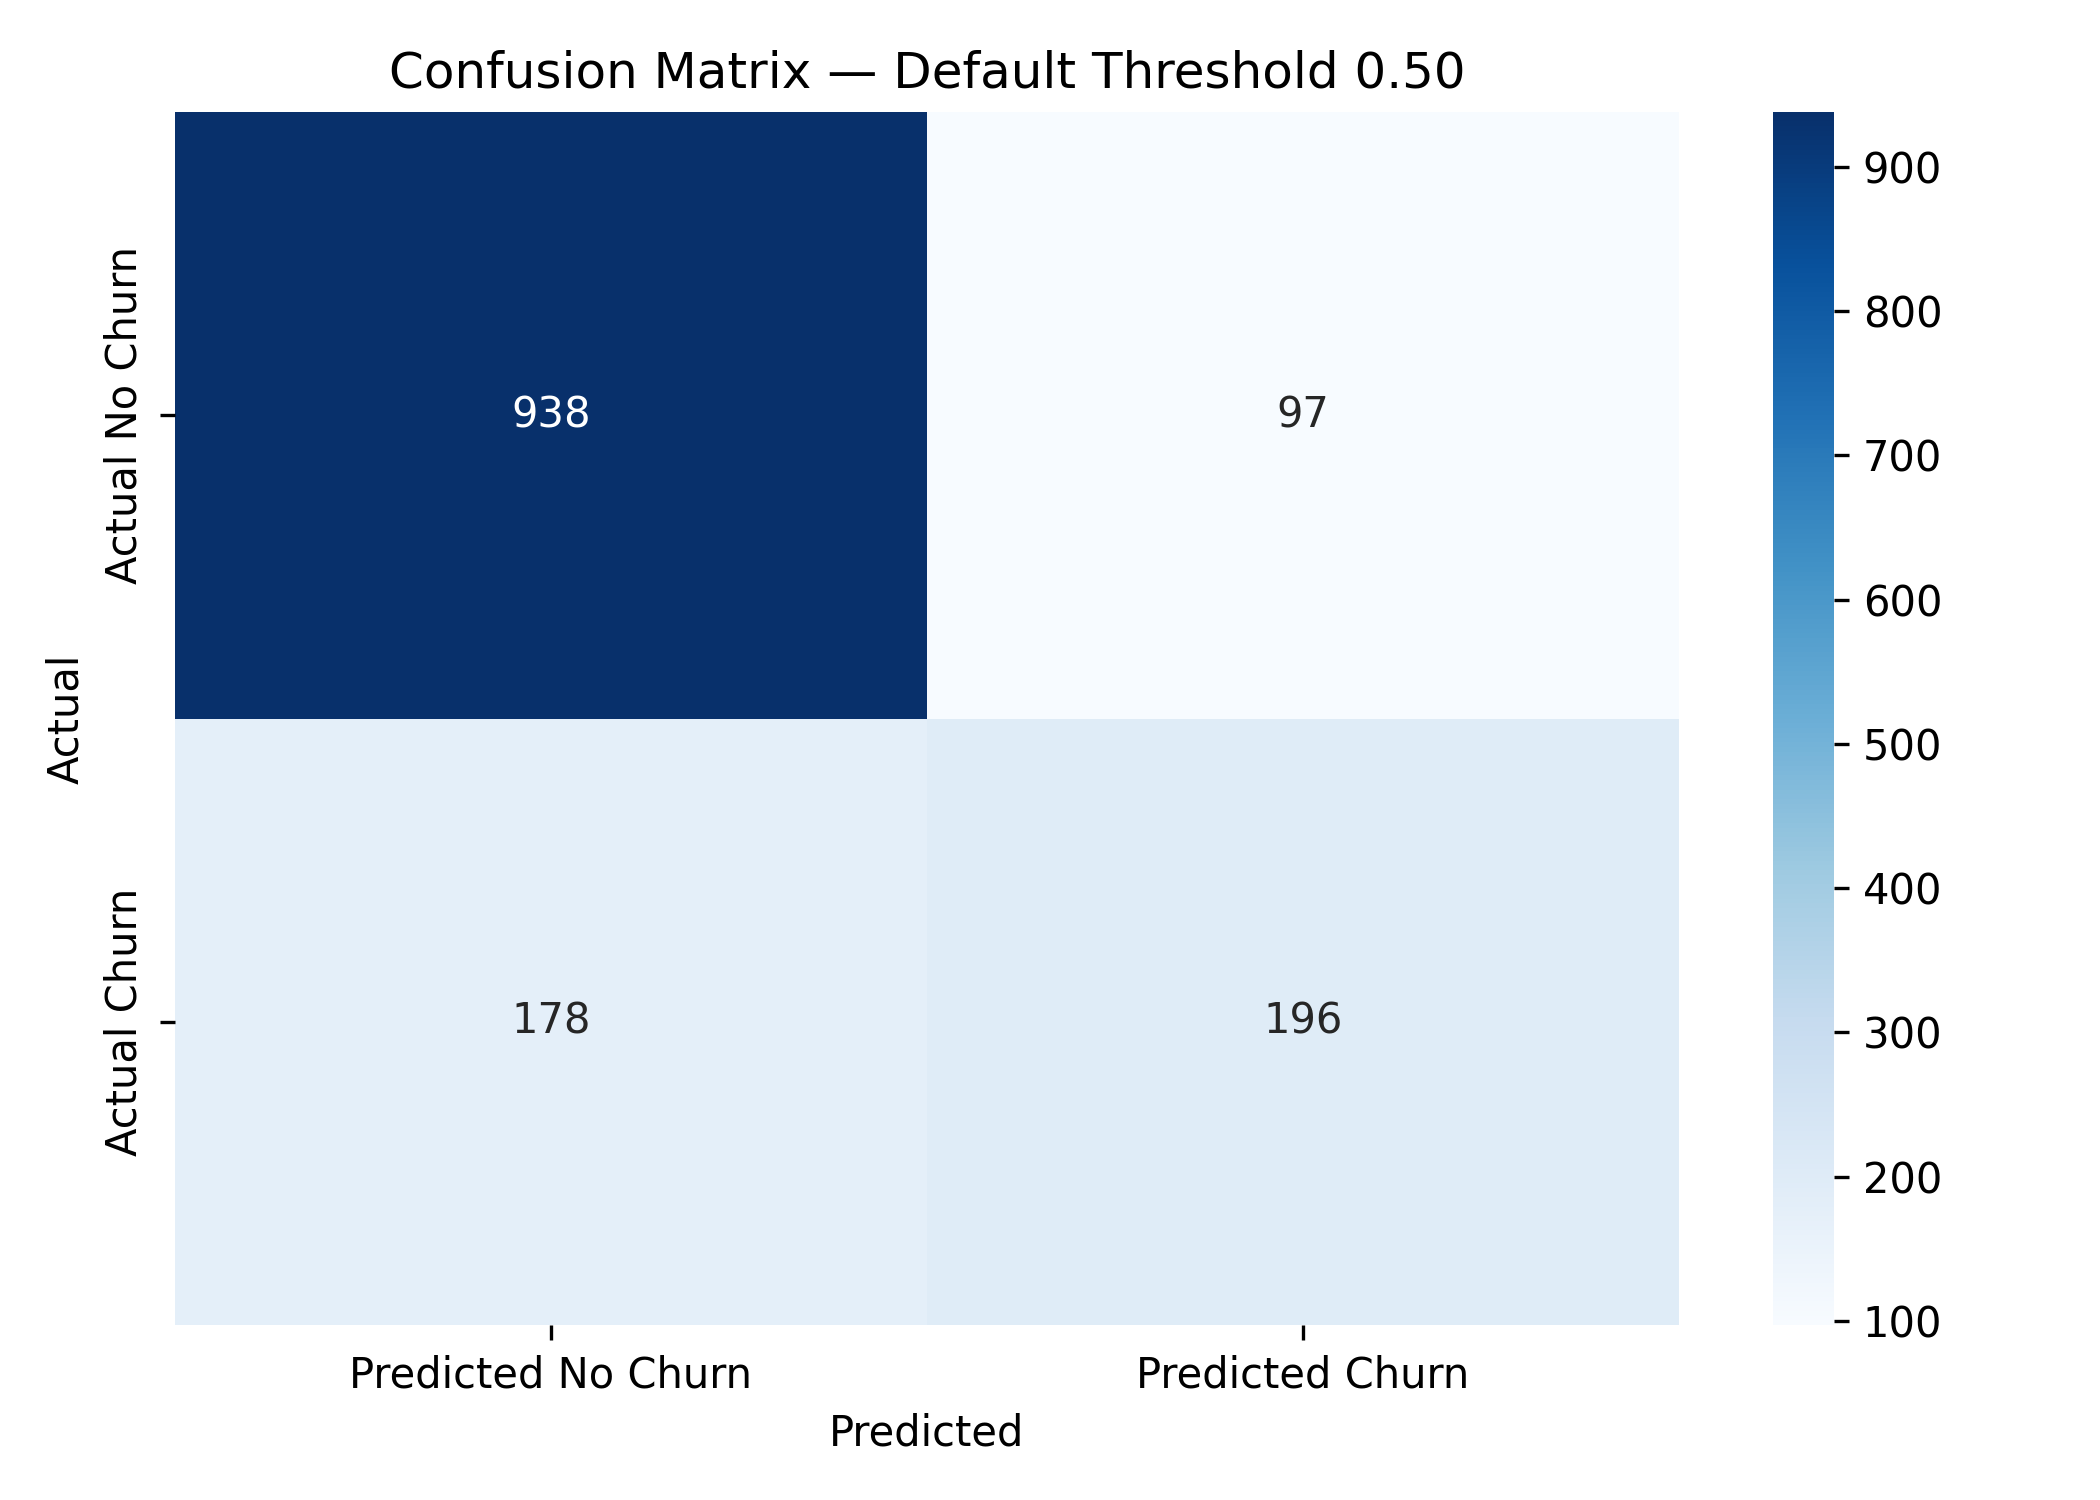

In [18]:
display(Image(filename=FIGURES_DIR / "confusion_matrix_default_threshold.png"))

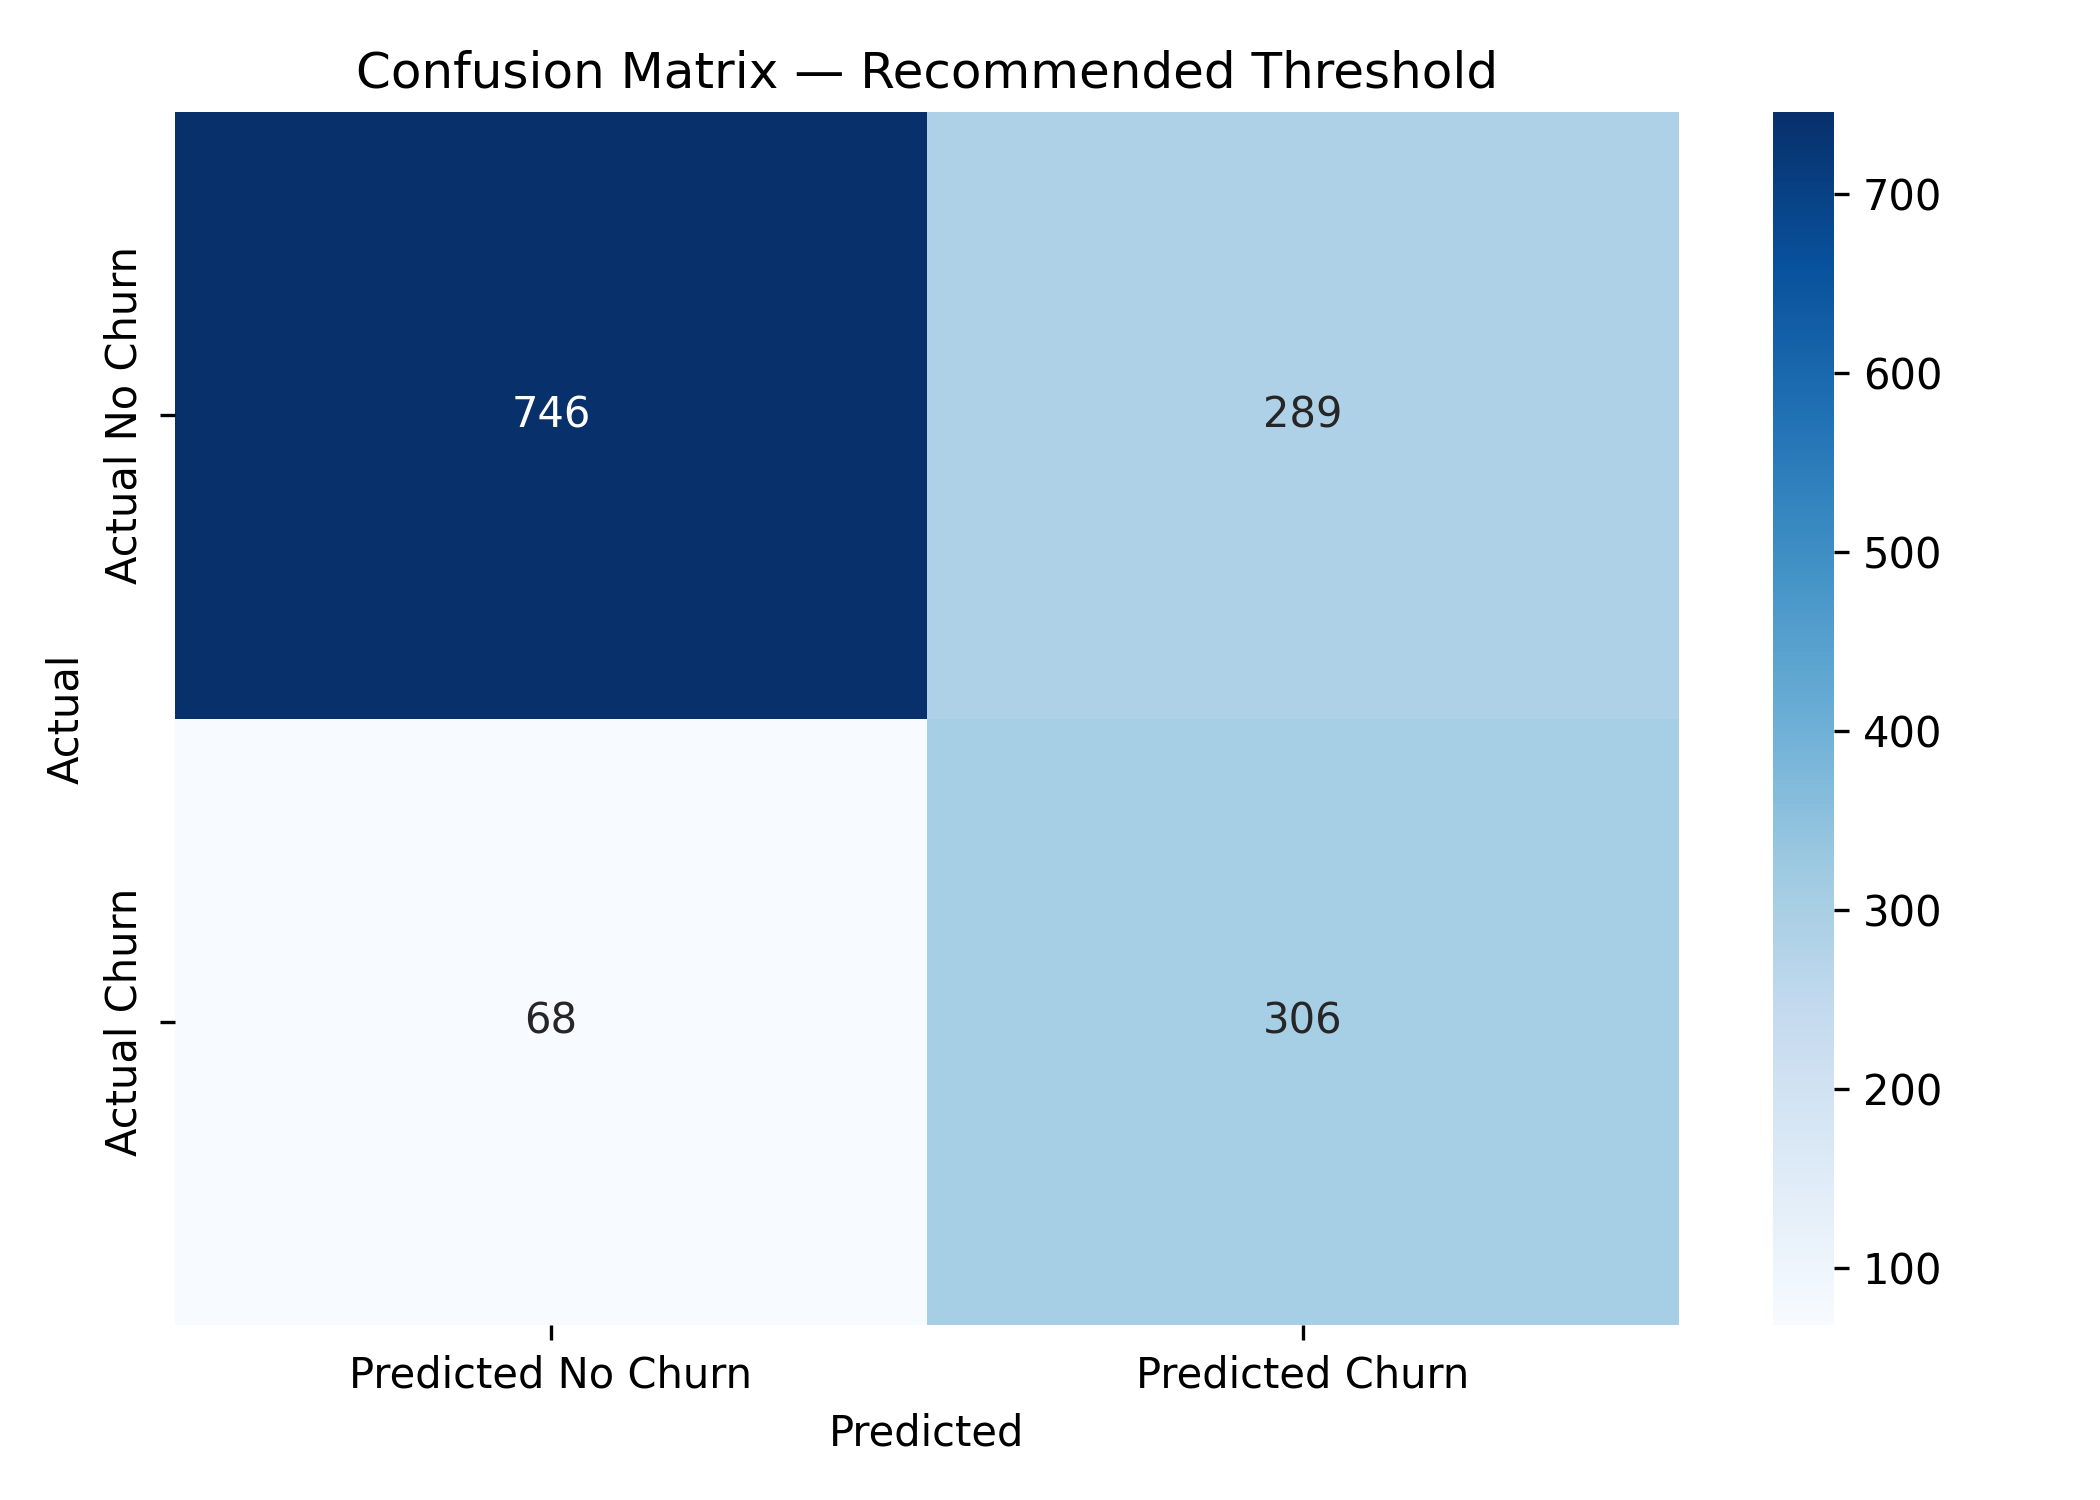

In [19]:
display(Image(filename=FIGURES_DIR / "confusion_matrix_recommended_threshold.png"))

## Confusion Matrix Interpretation

The recommended threshold prioritizes recall.

This is appropriate when the business objective is to identify more customers at risk of churn before they leave.

If the retention team has limited contact capacity, a higher threshold could be used to prioritize fewer customers with higher churn probability.

In [20]:
gradient_importance.head(15)

,raw_feature_name,feature,feature_group,importance
0,categorical__Contract_Month-to-month,Contract_Month-to-month,categorical,0.3767
1,numeric__tenure,tenure,numeric,0.1357
2,numeric__TotalCharges,TotalCharges,numeric,0.0908
3,categorical__InternetService_Fiber optic,InternetService_Fiber optic,categorical,0.0873
4,numeric__MonthlyCharges,MonthlyCharges,numeric,0.0783
5,categorical__OnlineSecurity_No,OnlineSecurity_No,categorical,0.0657
6,categorical__TechSupport_No,TechSupport_No,categorical,0.0467
7,categorical__PaymentMethod_Electronic check,PaymentMethod_Electronic check,categorical,0.0417
8,categorical__PaperlessBilling_Yes,PaperlessBilling_Yes,categorical,0.0130
9,categorical__MultipleLines_No,MultipleLines_No,categorical,0.0112


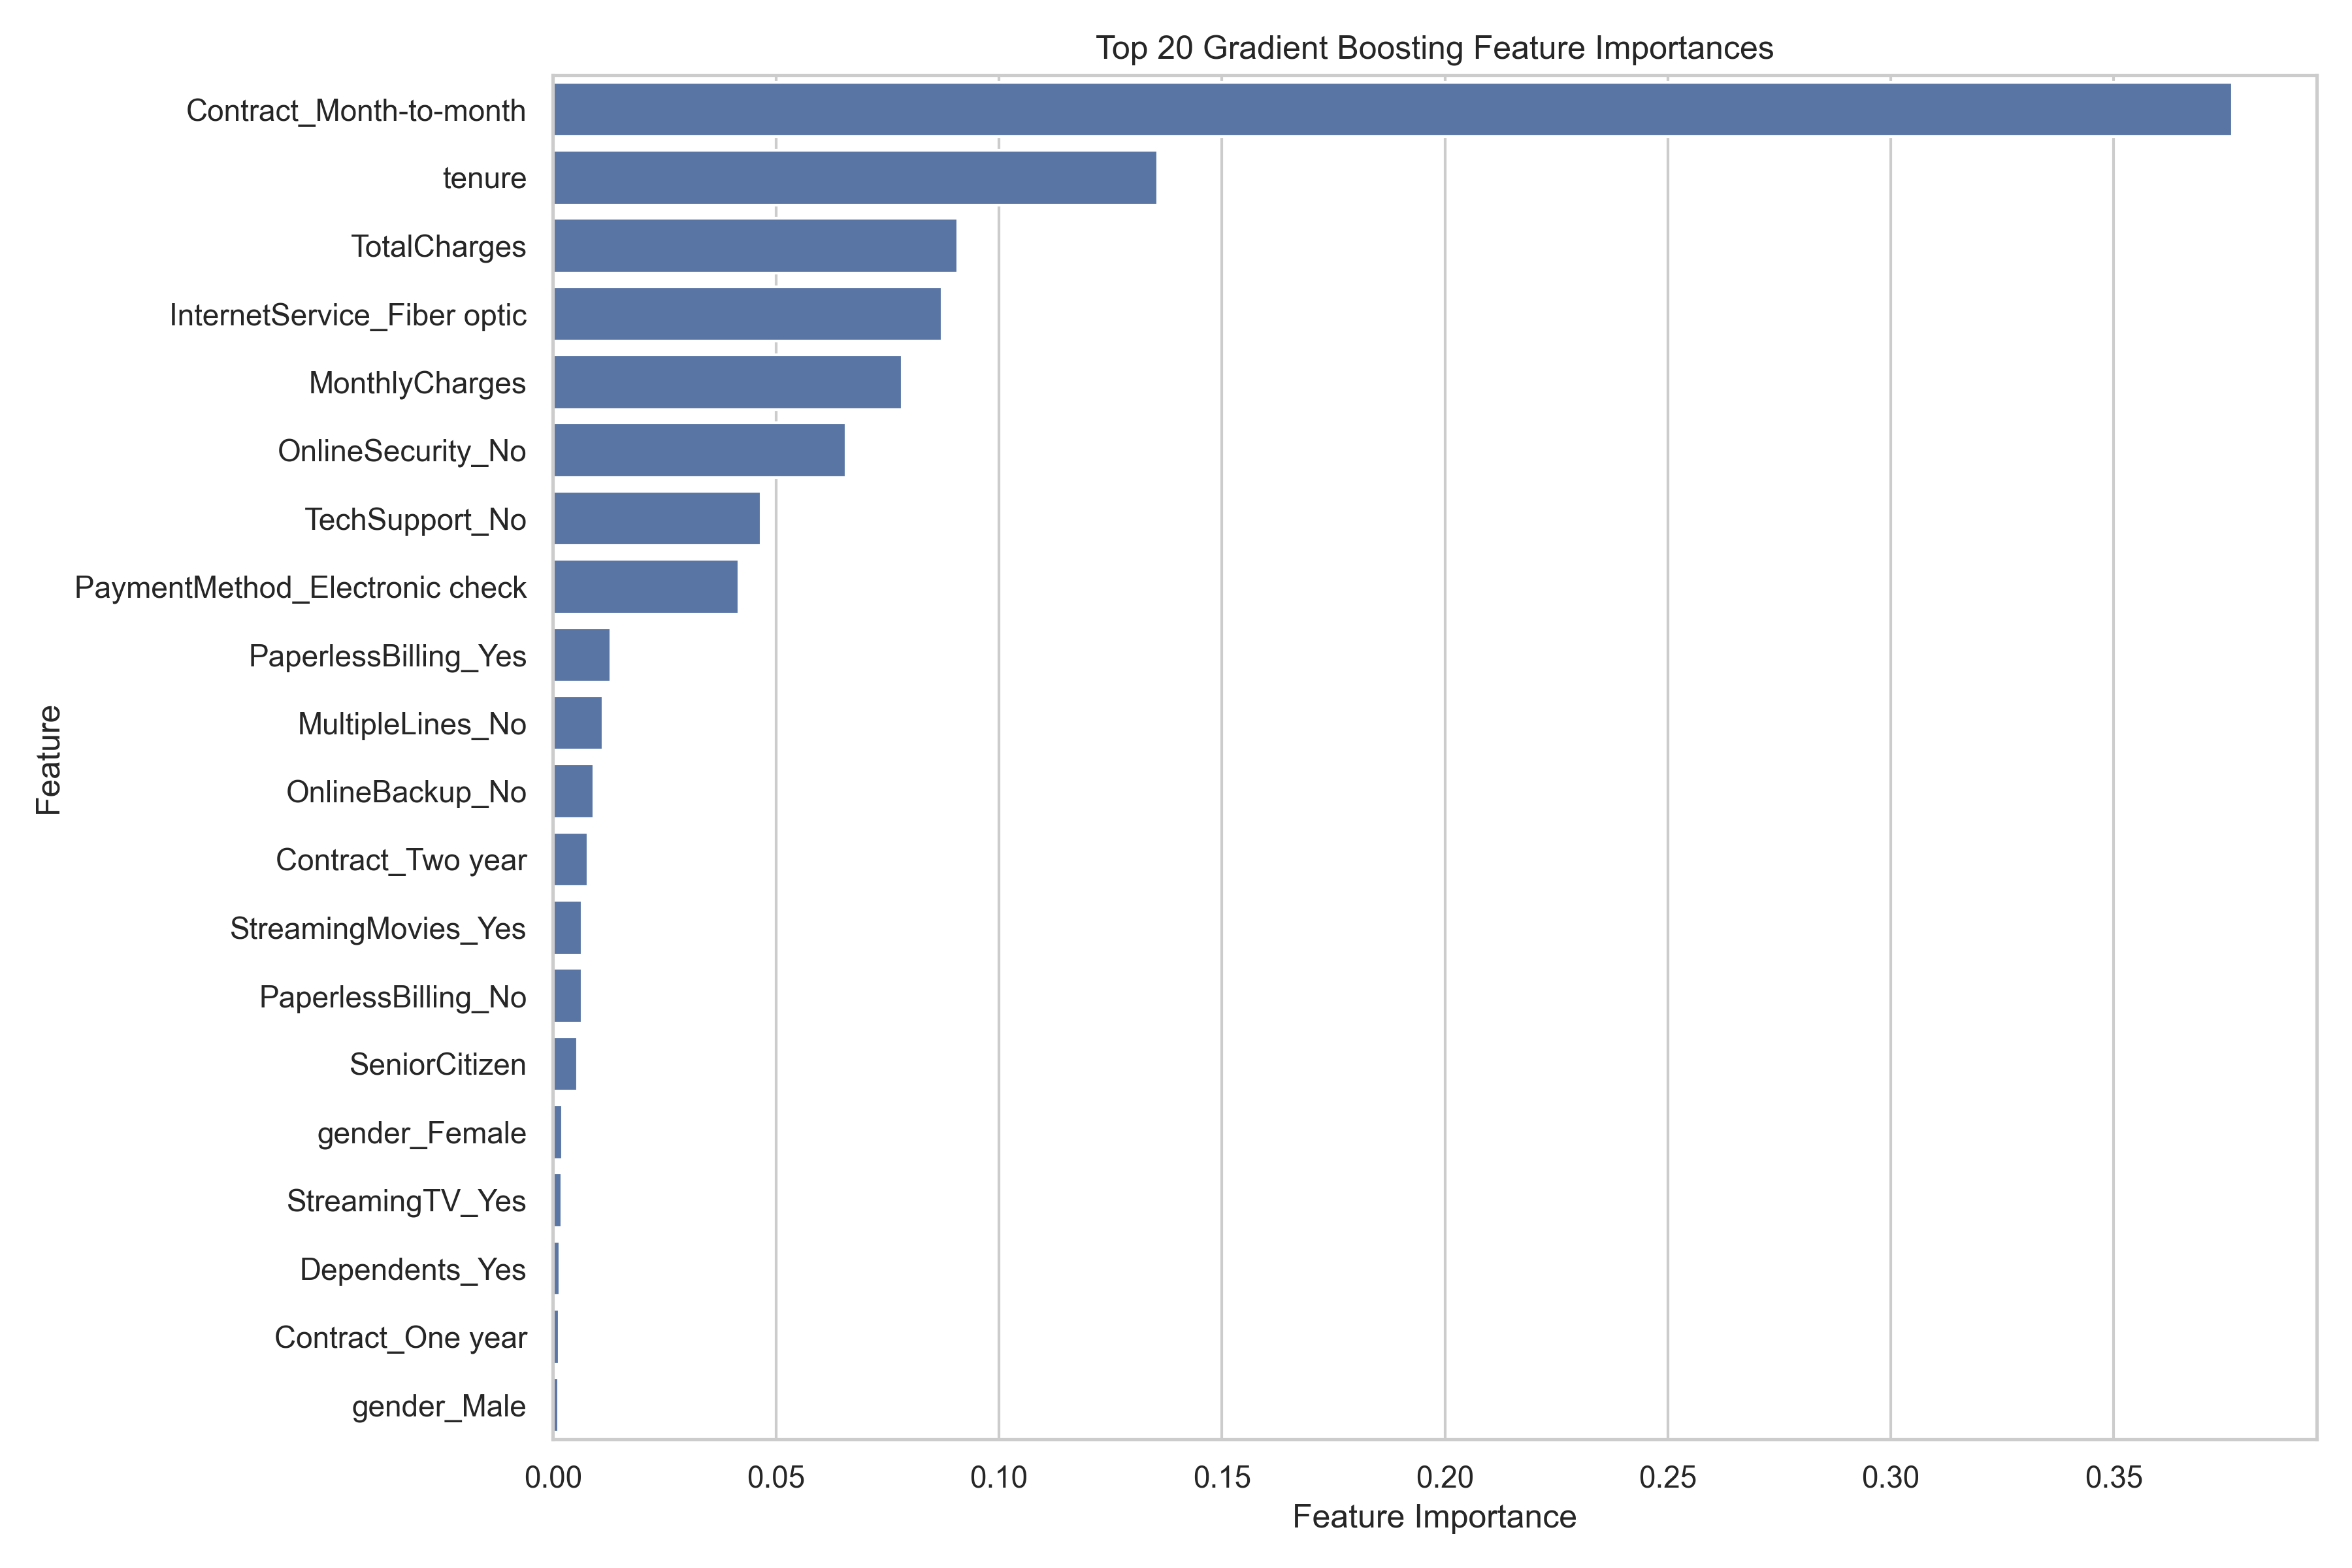

In [21]:
display(Image(filename=FIGURES_DIR / "top_gradient_boosting_feature_importance.png"))

## Predictive Feature Importance

Gradient Boosting identifies the most important predictive features as:

- Month-to-month contract,
- tenure,
- TotalCharges,
- Fiber optic internet service,
- MonthlyCharges,
- lack of OnlineSecurity,
- lack of TechSupport,
- Electronic check payment method.

Feature importance shows which variables help prediction, but it does not directly show whether they increase or decrease churn probability.

In [22]:
top_positive = (
    logistic_coefficients
    .sort_values("coefficient", ascending=False)
    .head(15)
)

top_positive[
    ["feature", "feature_group", "coefficient", "odds_ratio"]
]

,feature,feature_group,coefficient,odds_ratio
2,InternetService_Fiber optic,categorical,0.7080,2.0299
4,Contract_Month-to-month,categorical,0.6577,1.9304
6,TotalCharges,numeric,0.4897,1.6318
14,StreamingMovies_Yes,categorical,0.2754,1.3170
16,StreamingTV_Yes,categorical,0.2622,1.2997
17,PaymentMethod_Electronic check,categorical,0.2403,1.2716
20,OnlineSecurity_No,categorical,0.1990,1.2202
23,TechSupport_No,categorical,0.1655,1.1800
26,MultipleLines_Yes,categorical,0.1328,1.1421
37,DeviceProtection_Yes,categorical,0.0742,1.0770


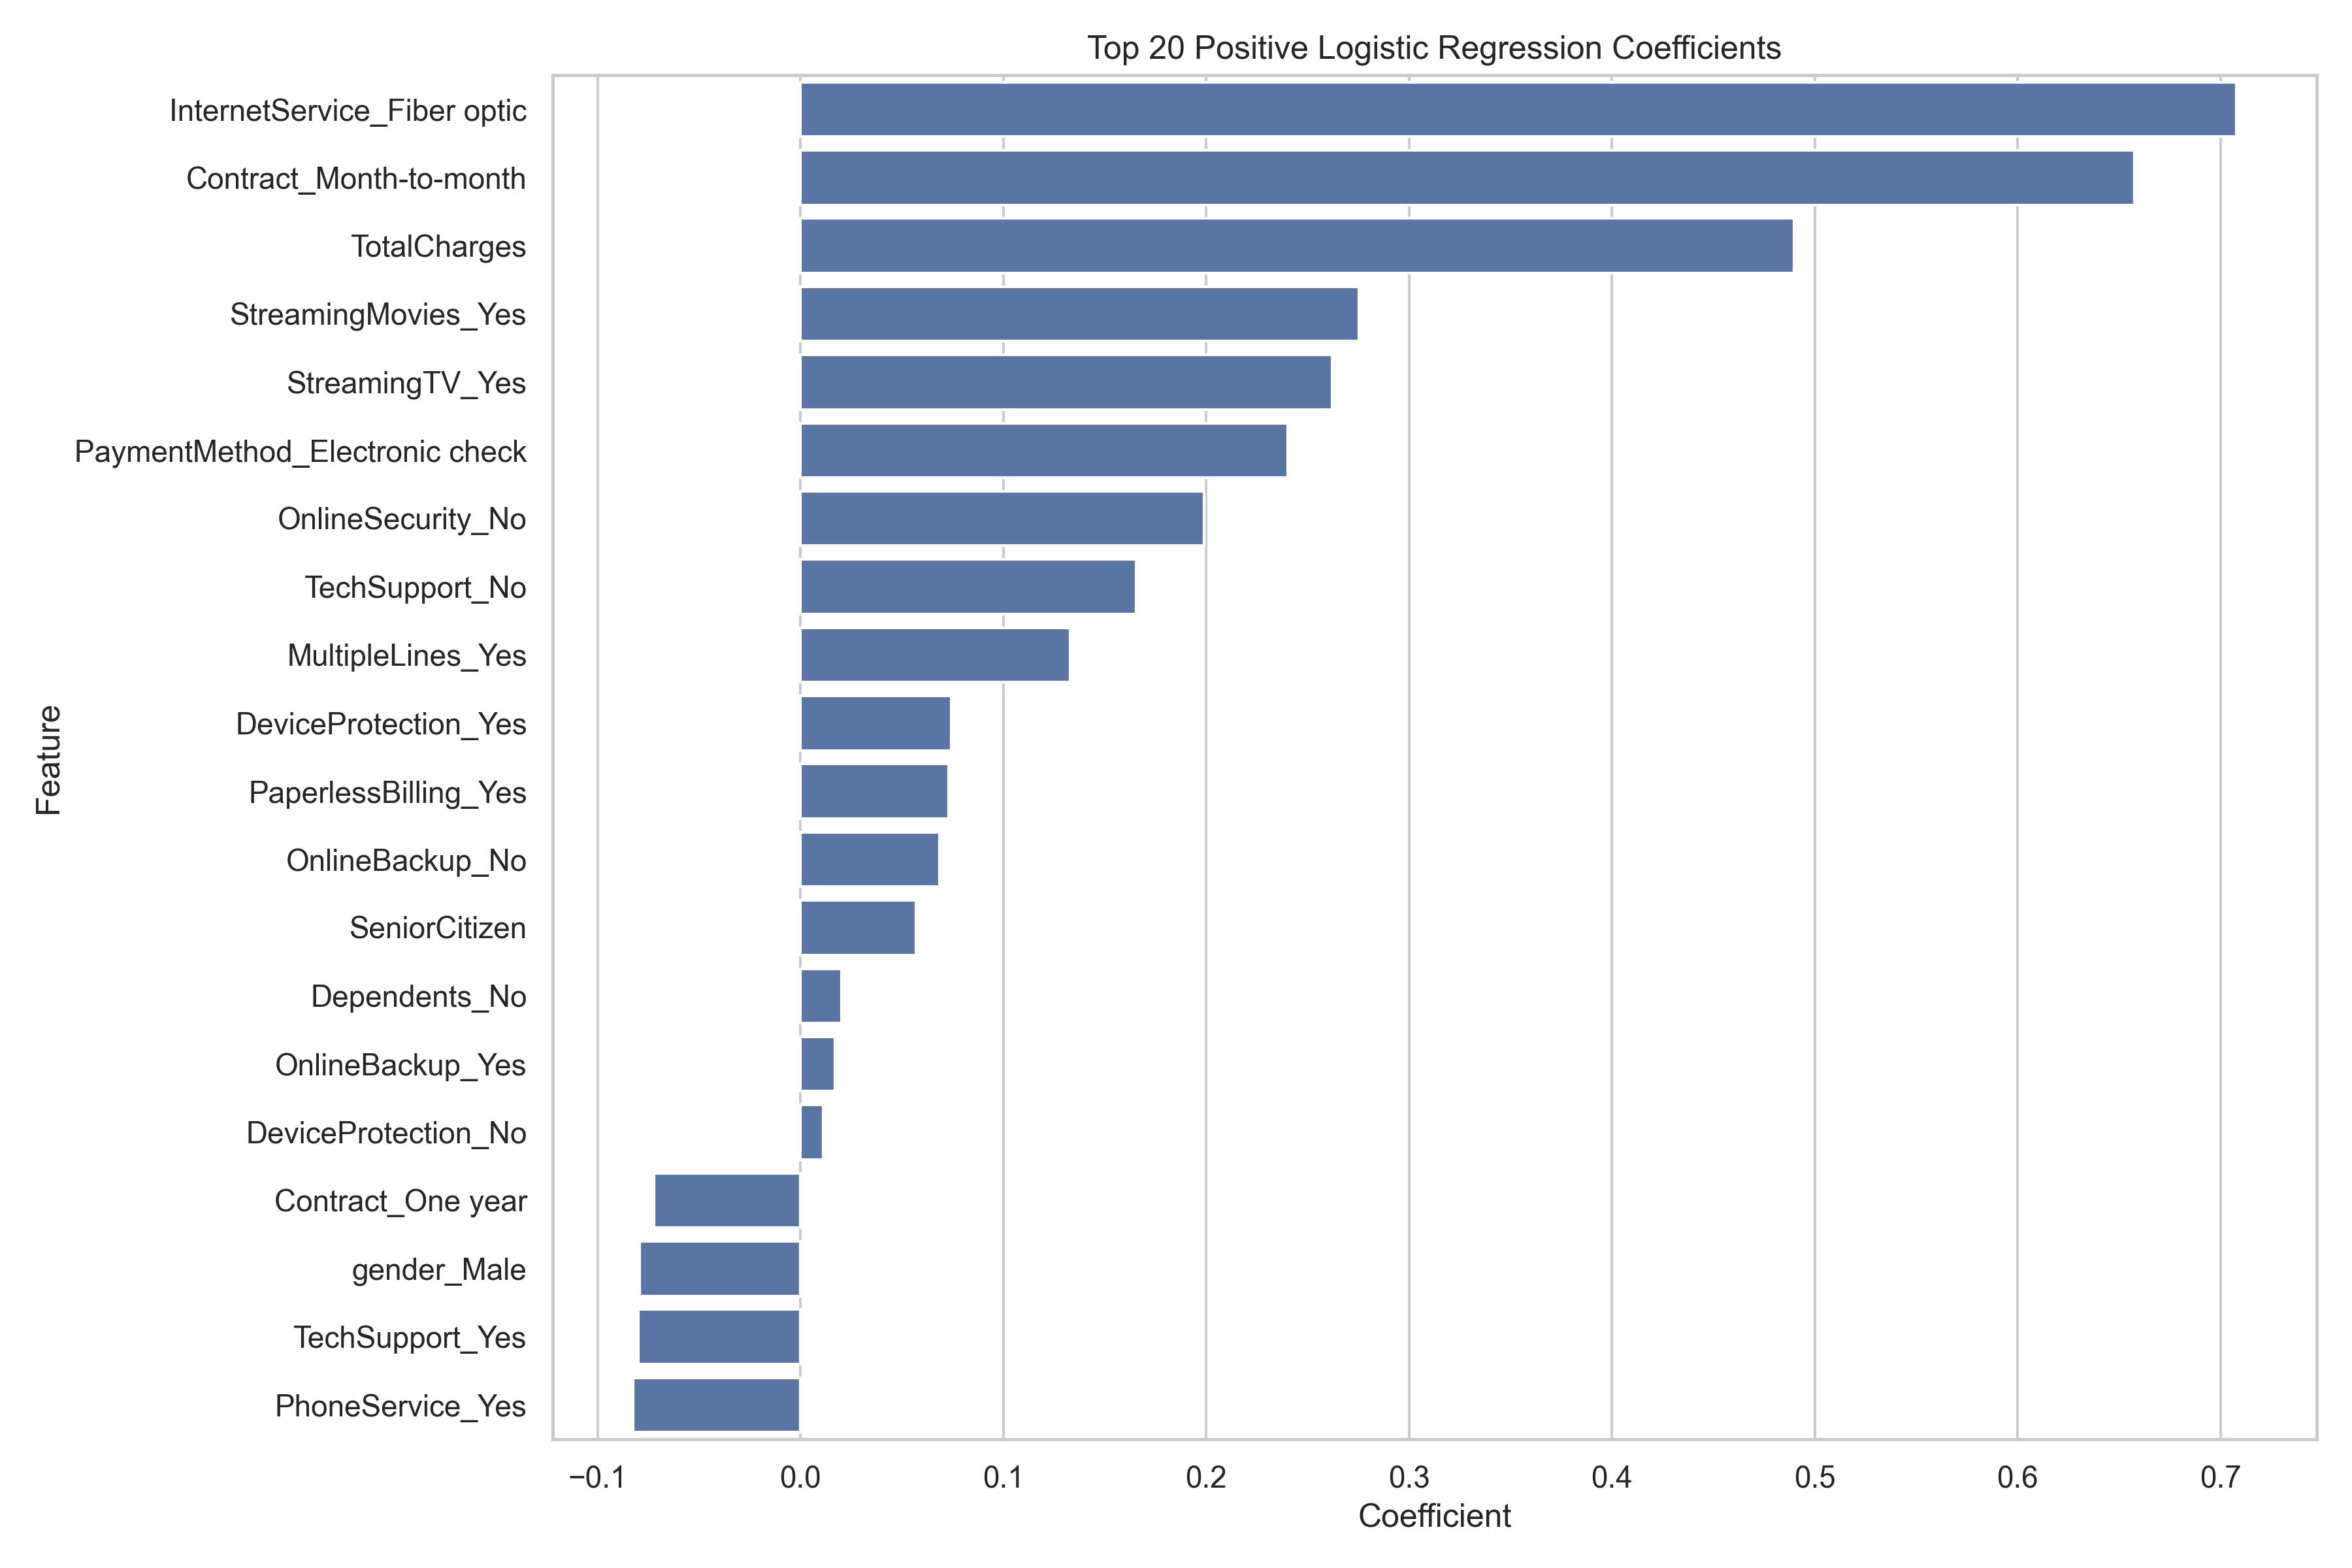

In [23]:
display(Image(filename=FIGURES_DIR / "top_positive_logistic_coefficients.png"))

## Positive Churn Associations

Logistic Regression suggests that the following features are positively associated with churn:

- Fiber optic internet service,
- month-to-month contract,
- higher TotalCharges,
- streaming services,
- electronic check payment,
- no OnlineSecurity,
- no TechSupport.

These are associations, not causal effects.

In [24]:
top_negative = (
    logistic_coefficients
    .sort_values("coefficient", ascending=True)
    .head(15)
)

top_negative[
    ["feature", "feature_group", "coefficient", "odds_ratio"]
]

,feature,feature_group,coefficient,odds_ratio
0,tenure,numeric,-1.1544,0.3152
1,Contract_Two year,categorical,-0.7755,0.4605
3,MonthlyCharges,numeric,-0.6761,0.5086
5,InternetService_DSL,categorical,-0.6225,0.5366
7,TechSupport_No internet service,categorical,-0.2754,0.7593
10,OnlineSecurity_No internet service,categorical,-0.2754,0.7593
9,InternetService_No,categorical,-0.2754,0.7593
8,DeviceProtection_No internet service,categorical,-0.2754,0.7593
12,StreamingTV_No internet service,categorical,-0.2754,0.7593
13,OnlineBackup_No internet service,categorical,-0.2754,0.7593


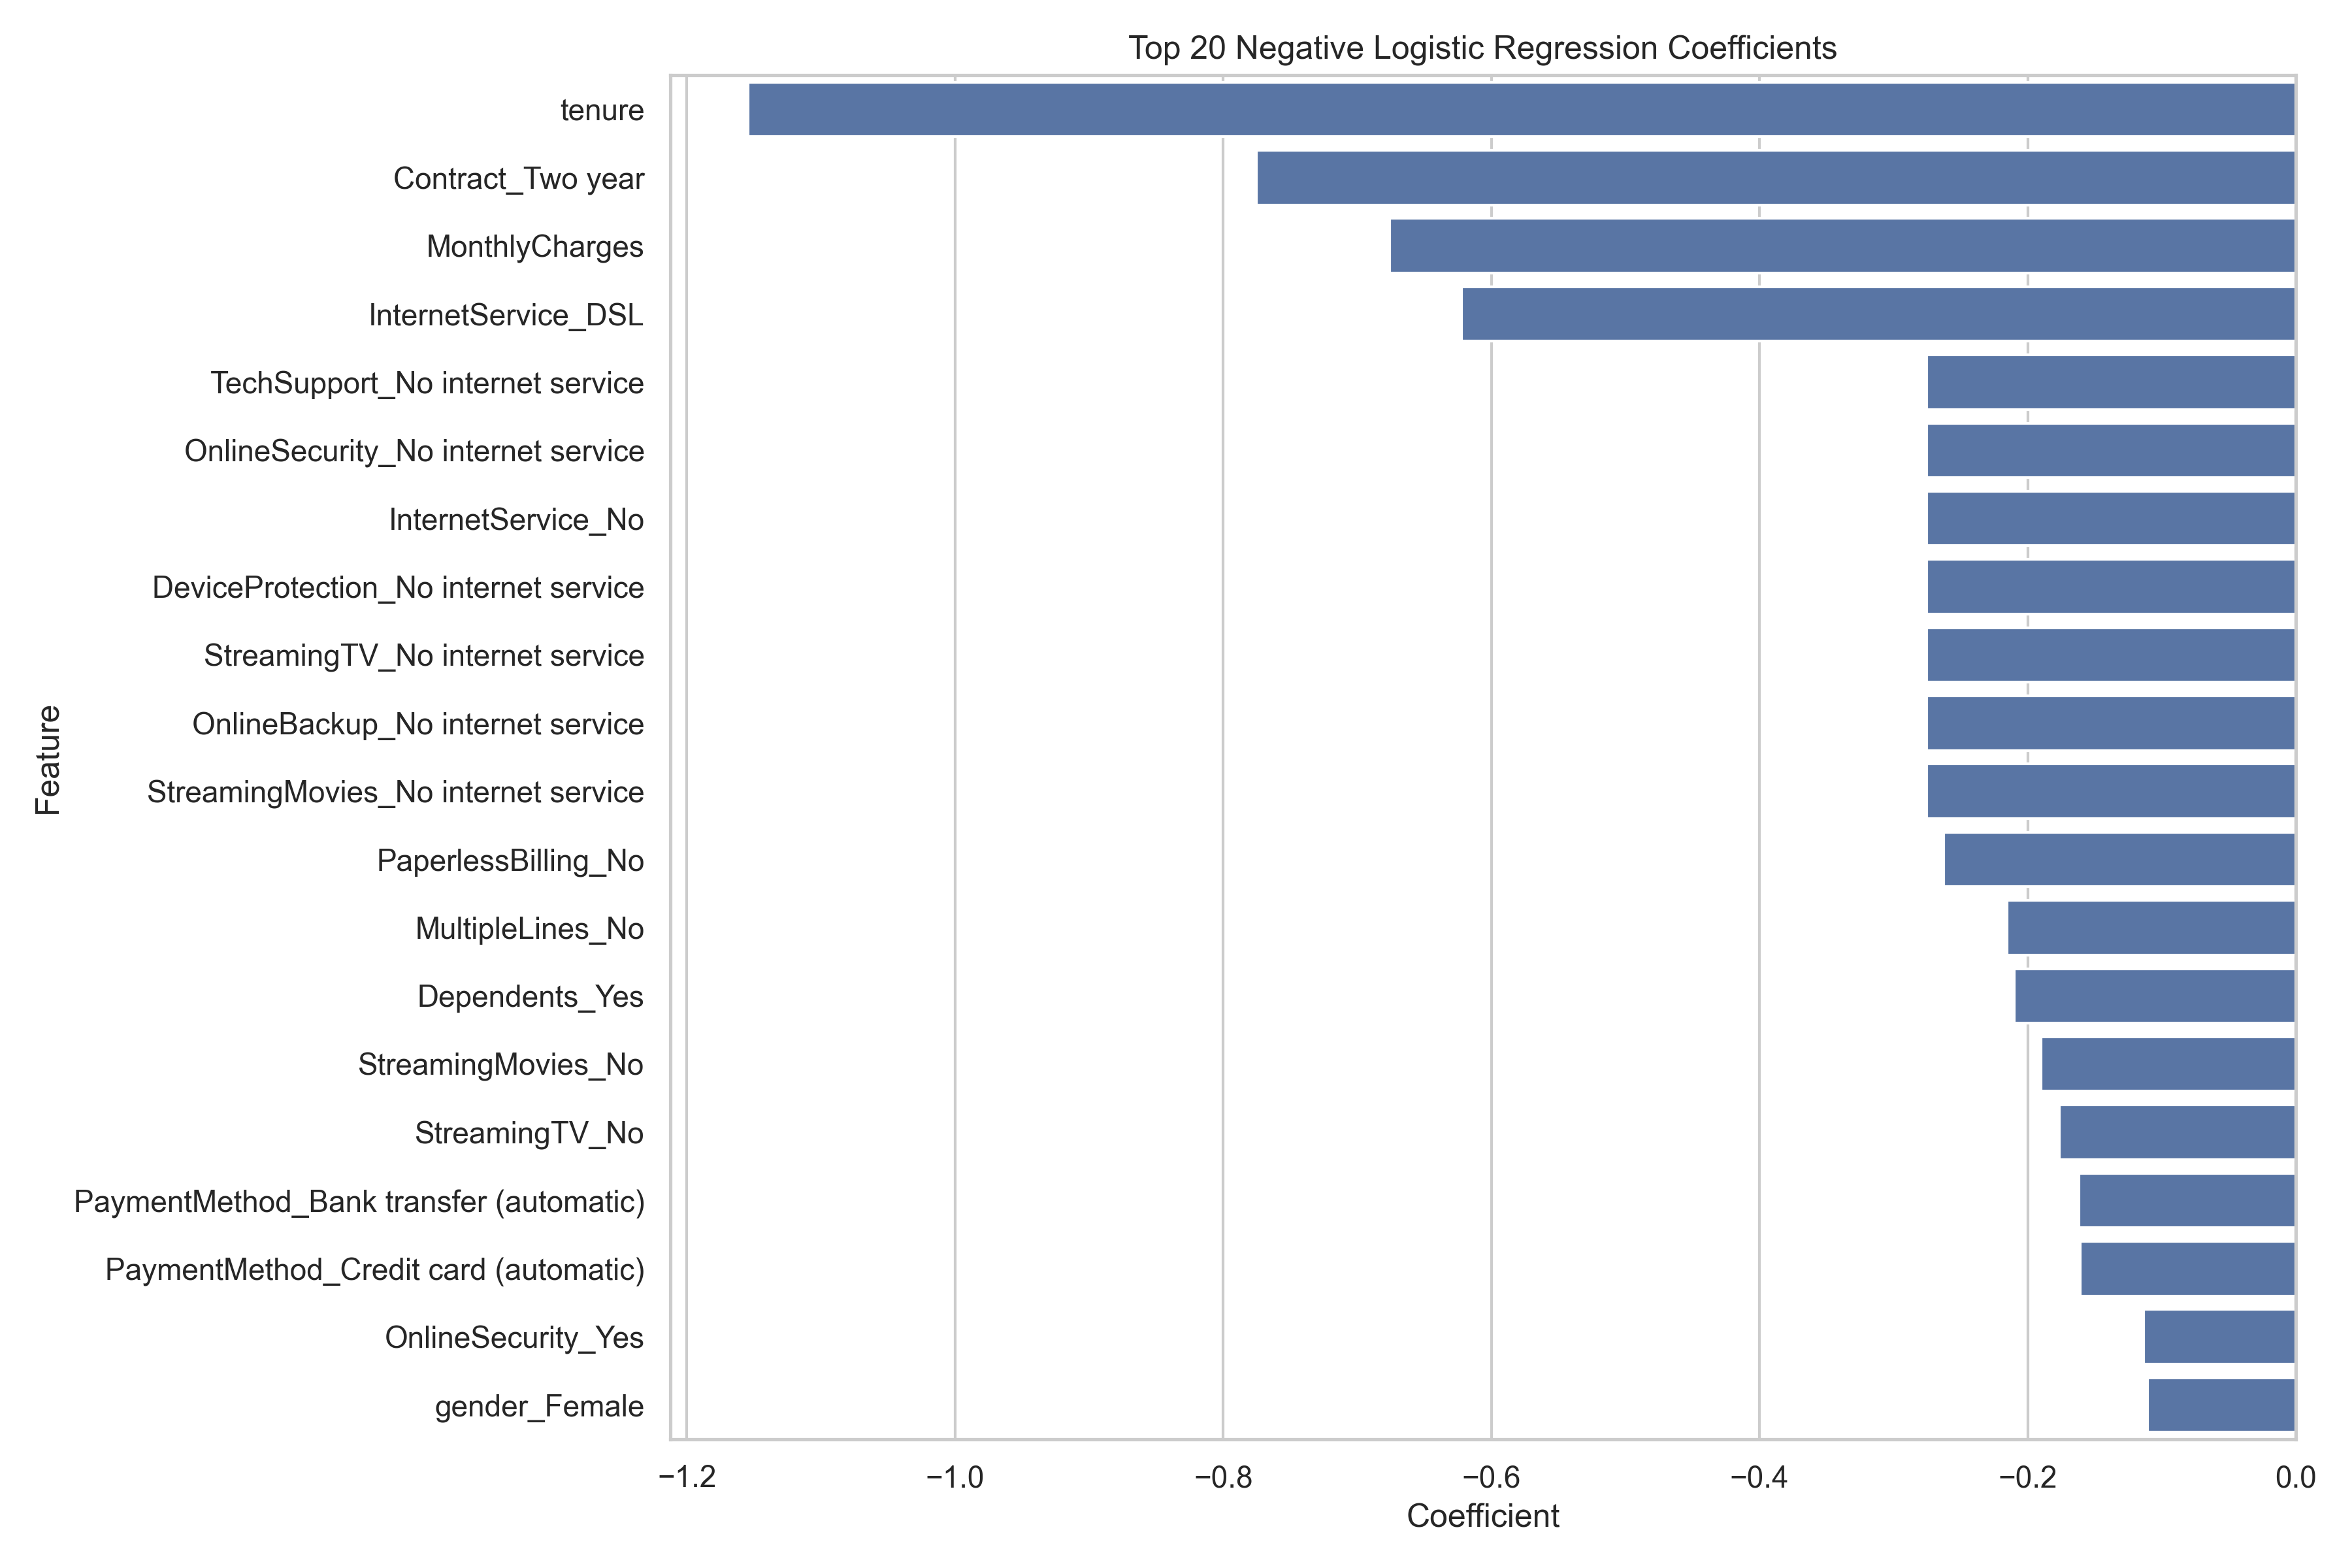

In [25]:
display(Image(filename=FIGURES_DIR / "top_negative_logistic_coefficients.png"))

## Negative Churn Associations

Logistic Regression suggests that longer tenure, two-year contracts, DSL service, no internet service, no paperless billing, and having dependents are negatively associated with churn.

This aligns with business intuition: longer relationship duration and stronger contractual commitment are associated with lower churn risk.

## Key Findings

- The churn dataset has moderate class imbalance: 26.54% churn and 73.46% no churn.
- Accuracy is not enough because a naive majority-class model reaches 73.46% accuracy while detecting no churners.
- Gradient Boosting achieved the strongest ROC-AUC and Average Precision performance.
- Cross-validation confirmed that Gradient Boosting is the most stable model for churn risk ranking.
- The default threshold of 0.50 misses too many churners.
- A threshold of 0.24 provides a better recall-oriented retention strategy.
- At threshold 0.24, the model captures 306 churners and misses 68.
- Important churn signals include month-to-month contract, tenure, fiber optic service, TotalCharges, MonthlyCharges, lack of OnlineSecurity, lack of TechSupport, and electronic check payment.

## Business Recommendations

- Use the model to prioritize retention outreach, not as an automatic decision system.
- Use threshold 0.24 when the business wants to maximize churn detection.
- Use a higher threshold when the retention team has limited contact capacity.
- Focus retention campaigns on month-to-month customers with short tenure and high-risk service patterns.
- Investigate why fiber optic customers show higher churn.
- Improve service support and security offerings because lack of OnlineSecurity and TechSupport is strongly associated with churn risk.

## Limitations

- The dataset is static and does not include time-based customer behavior.
- The model does not include support tickets, call center history, complaints, customer satisfaction, or competitor pricing.
- Feature interpretation is associative, not causal.
- Threshold selection should be adjusted based on actual campaign cost, customer lifetime value, and retention team capacity.